In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
sample = data.query('FICO_orig_time <= 650')

print(sample.shape)

(22694, 28)


In [4]:
ref = data.sample(int(0.8*len(data)), random_state=12345).index
data.loc[:, 'FICO_orig_time2'] = data.FICO_orig_time
data.loc[:, 'FICO_orig_time2'].iloc[ref] =np.NaN

print(data[['FICO_orig_time', 'FICO_orig_time2']])

       FICO_orig_time  FICO_orig_time2
0                 587              NaN
1                 587              NaN
2                 587              NaN
3                 587            587.0
4                 587            587.0
...               ...              ...
62173             708              NaN
62174             708              NaN
62175             708              NaN
62176             708              NaN
62177             708            708.0

[62178 rows x 2 columns]


In [5]:
data2 = data[['FICO_orig_time', 'FICO_orig_time2']]

print(data2.describe().round(decimals=2))

       FICO_orig_time  FICO_orig_time2
count        62178.00         12436.00
mean           673.36           673.90
std             72.10            72.03
min            429.00           459.00
25%            628.00           628.00
50%            675.00           676.00
75%            730.00           730.00
max            819.00           819.00


In [6]:
data3 = data2.dropna(subset=['FICO_orig_time2'])

print(data3.describe().round(decimals=2))

       FICO_orig_time  FICO_orig_time2
count        12436.00         12436.00
mean           673.90           673.90
std             72.03            72.03
min            459.00           459.00
25%            628.00           628.00
50%            676.00           676.00
75%            730.00           730.00
max            819.00           819.00


In [7]:
data['FICO_orig_time_cat'] = 0  
data.loc[data['FICO_orig_time2'] >= 400, 'FICO_orig_time_cat'] = 1  
data.loc[data['FICO_orig_time2'] >= 450, 'FICO_orig_time_cat'] = 2  
data.loc[data['FICO_orig_time2'] >= 500, 'FICO_orig_time_cat'] = 3  
data.loc[data['FICO_orig_time2'] >= 550, 'FICO_orig_time_cat'] = 4  
data.loc[data['FICO_orig_time2'] >= 600, 'FICO_orig_time_cat'] = 5  
data.loc[data['FICO_orig_time2'] >= 650, 'FICO_orig_time_cat'] = 6  
data.loc[data['FICO_orig_time2'] >= 700, 'FICO_orig_time_cat'] = 7  
data.loc[data['FICO_orig_time2'] >= 750, 'FICO_orig_time_cat'] = 8  
data.loc[data['FICO_orig_time2'] >= 800, 'FICO_orig_time_cat'] = 9  

data['FICO_i1'] = pd.Categorical(data.FICO_orig_time_cat, ordered=False)

   FICO_orig_time_cat  FICO_orig_time2  default_time
0                   0              NaN         0.025
1                   2          486.522         0.014
2                   3          527.368         0.016
3                   4          575.773         0.032
4                   5          627.158         0.032
5                   6          674.019         0.026
6                   7          722.740         0.021
7                   8          770.454         0.011
8                   9          807.214         0.013


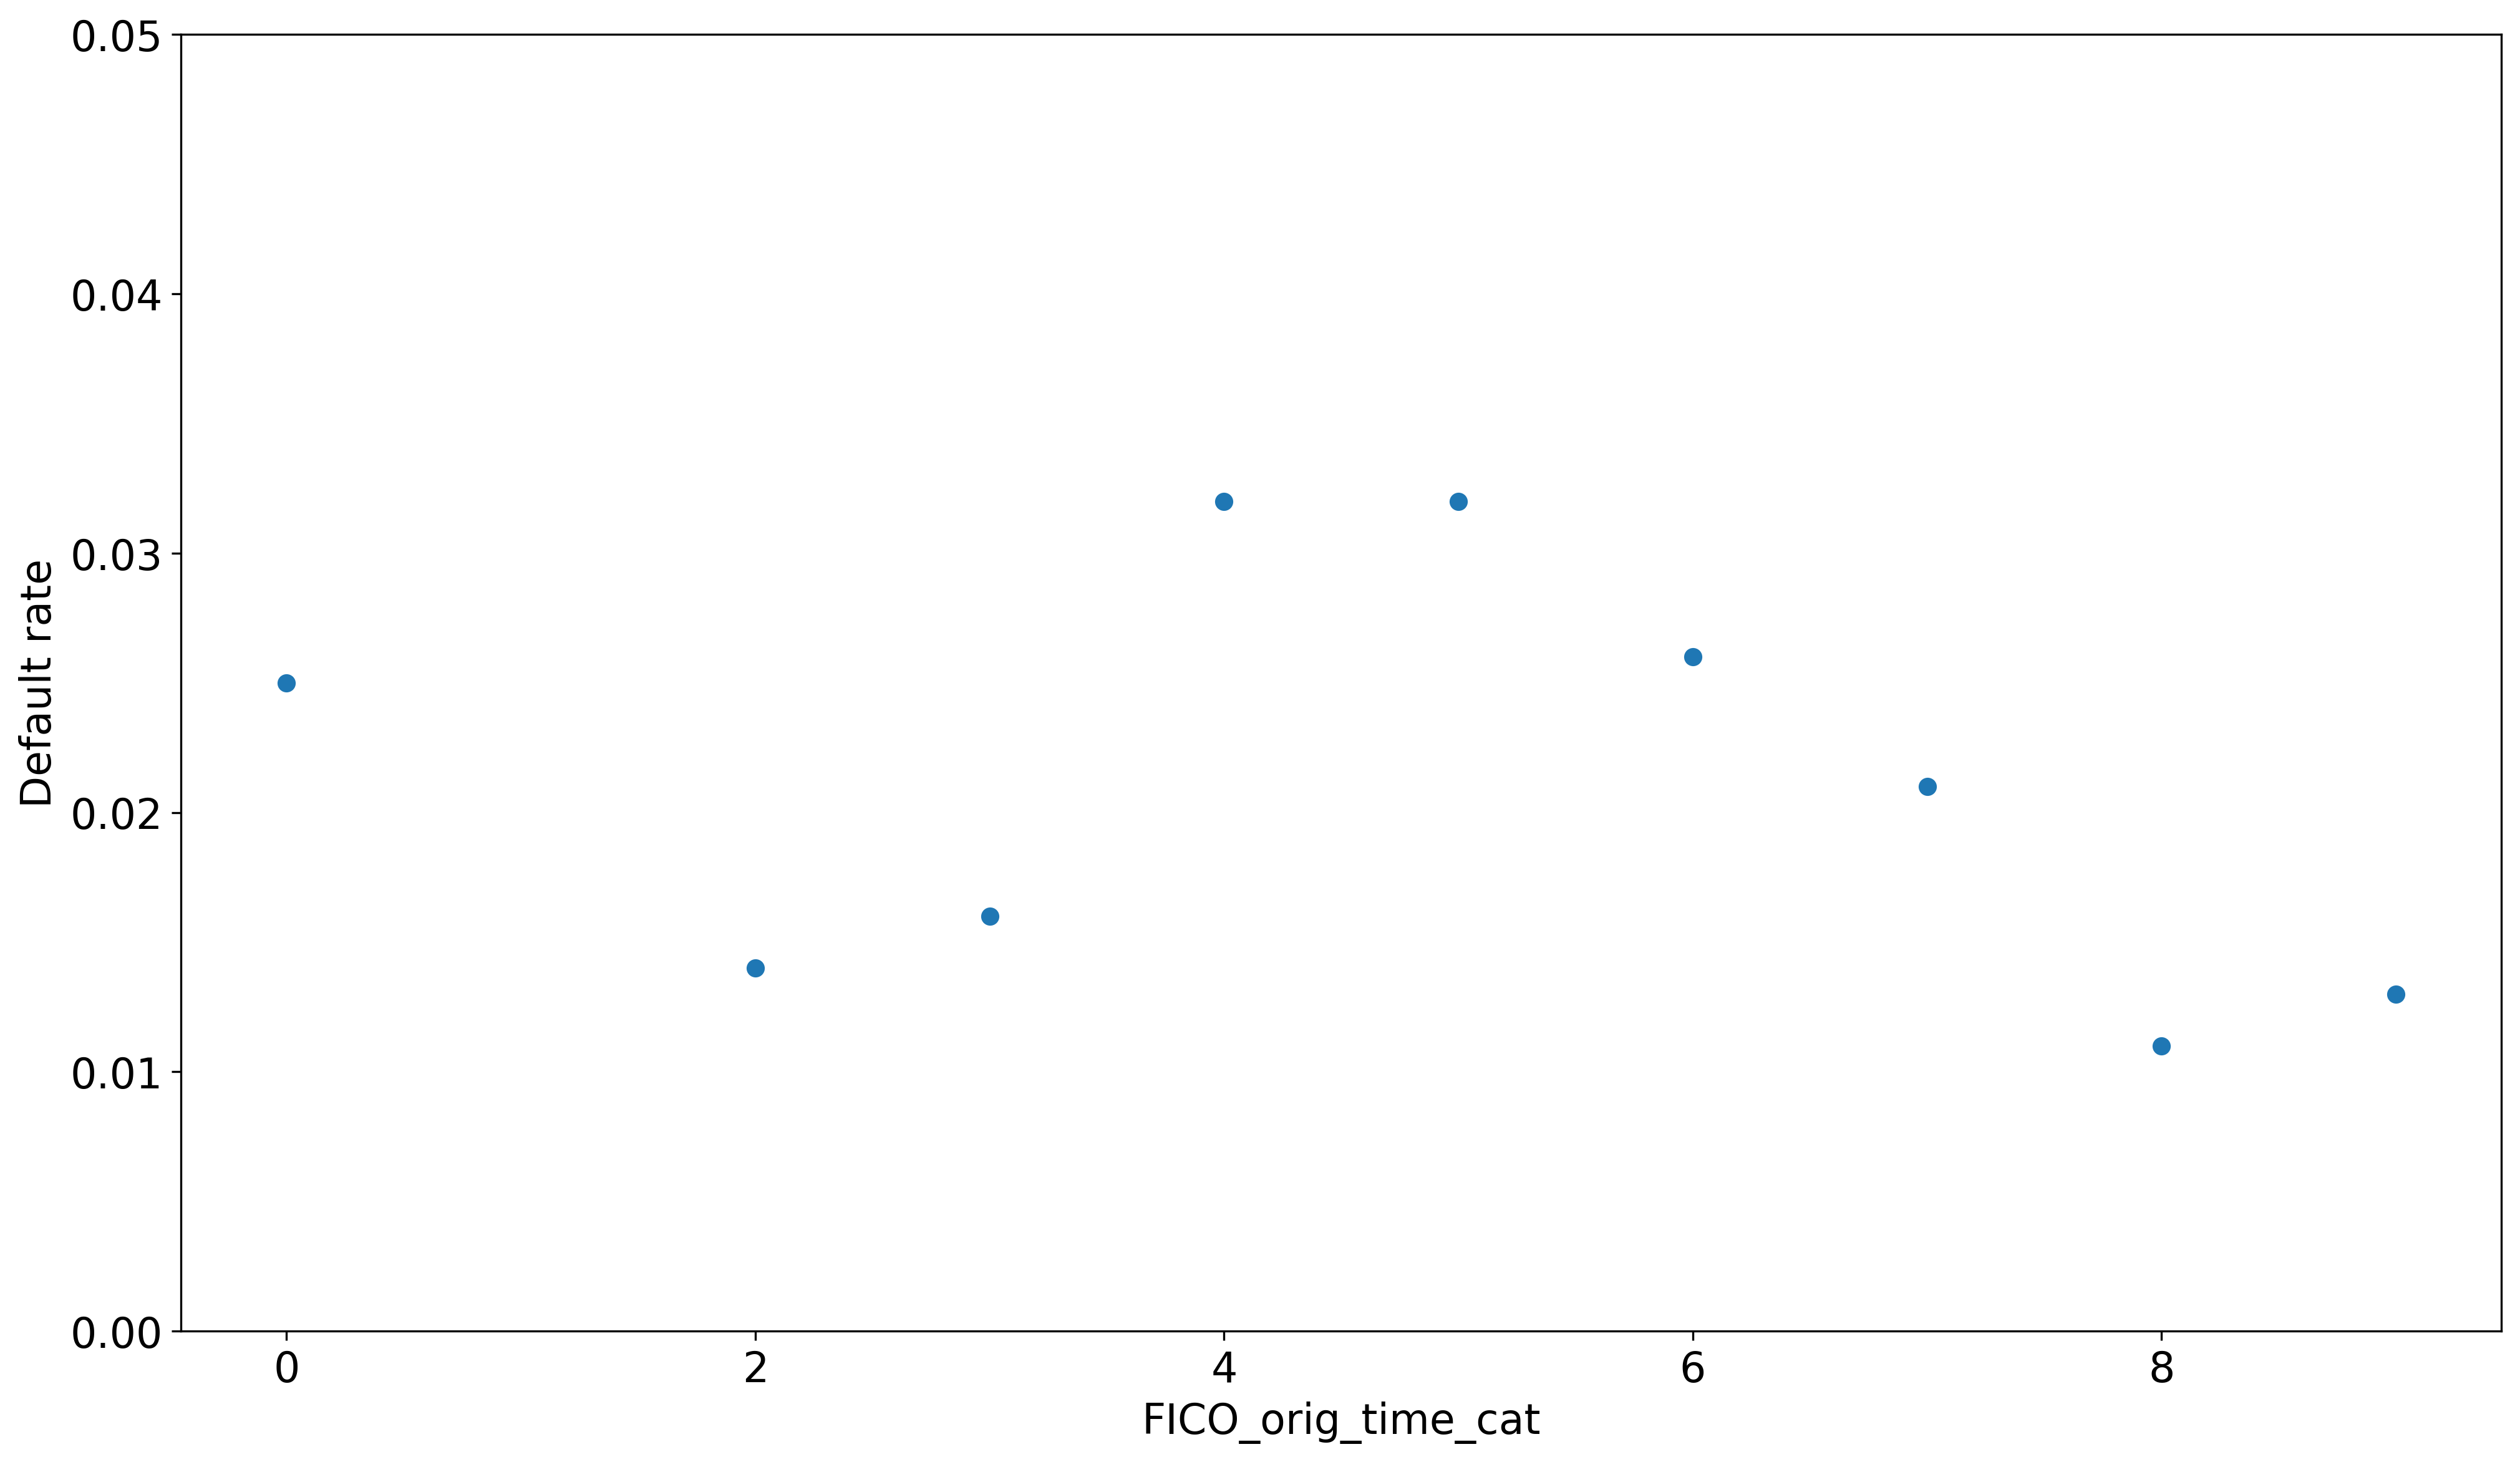

In [8]:
FICO_orig_time_cat_means = data.groupby('FICO_orig_time_cat')[['FICO_orig_time2', 'default_time']].mean().round(decimals=3).reset_index(drop=False)  

print(FICO_orig_time_cat_means.round(decimals=3))  

plt.scatter('FICO_orig_time_cat', 'default_time', data=FICO_orig_time_cat_means)  
plt.xlabel('FICO_orig_time_cat')  
plt.ylabel('Default rate')  
plt.ylim([0, 0.05])  
plt.show()  
data['FICO_i2'] = data.FICO_orig_time2  
data['FICO_i2']= data.FICO_i2.replace(np.NaN,673.938)

In [9]:
replace = data['FICO_orig_time2'].median()  
data.loc[:,'FICO_i3'] = data.FICO_orig_time2  
data.loc[:,'FICO_i3'] = data.FICO_i3.replace(np.NaN,replace)

In [10]:
fico_ols = smf.ols(formula='FICO_orig_time2 ~ LTV_time', data=data,).fit()  
data.loc[:,'FICO_fit'] = pd.DataFrame(fico_ols.predict(data))  
data.loc[:,'FICO_i4'] = data.FICO_orig_time2  
data.loc[:,'FICO_i4'] = data['FICO_i4'].fillna(data['FICO_fit'])  

print(data[['FICO_orig_time2', 'LTV_orig_time', 'FICO_fit']].round(decimals=2))

       FICO_orig_time2  LTV_orig_time  FICO_fit
0                  NaN           81.8    667.03
1                  NaN           81.8    667.04
2                  NaN           81.8    667.09
3                587.0           81.8    667.14
4                587.0           81.8    667.18
...                ...            ...       ...
62173              NaN           79.8    676.82
62174              NaN           79.8    675.75
62175              NaN           79.8    675.21
62176              NaN           79.8    675.17
62177            708.0           79.8    675.07

[62178 rows x 3 columns]


In [11]:
print(data[['FICO_i1', 'FICO_i2', 'FICO_i3', 'FICO_i4']].round(decimals=2))

      FICO_i1  FICO_i2  FICO_i3  FICO_i4
0           0   673.94    676.0   667.03
1           0   673.94    676.0   667.04
2           0   673.94    676.0   667.09
3           4   587.00    587.0   587.00
4           4   587.00    587.0   587.00
...       ...      ...      ...      ...
62173       0   673.94    676.0   676.82
62174       0   673.94    676.0   675.75
62175       0   673.94    676.0   675.21
62176       0   673.94    676.0   675.17
62177       7   708.00    708.0   708.00

[62178 rows x 4 columns]


In [12]:
print(data[['FICO_orig_time', 'LTV_orig_time', 'LTV_time', 'gdp_time']].describe().round(decimals=2)) 

       FICO_orig_time  LTV_orig_time  LTV_time  gdp_time
count        62178.00       62178.00  62153.00  62178.00
mean           673.36          78.70     83.32      1.38
std             72.10          10.24     28.11      1.95
min            429.00          50.10      0.00     -4.15
25%            628.00          75.00     67.06      1.10
50%            675.00          80.00     82.26      1.85
75%            730.00          80.00    100.77      2.69
max            819.00         119.80    803.51      5.13


In [13]:
data.loc[:,'LTV_time_p1'] = data.LTV_time.quantile(.01) 
data.loc[:,'LTV_time_p99'] = data.LTV_time.quantile(.99)  

data.loc[data['LTV_time'] <= data.LTV_time_p1, 'LTV_time'] = data.LTV_time_p1  
data.loc[data['LTV_time'] >= data.LTV_time_p99, 'LTV_time'] = data.LTV_time_p99  

print(data[['LTV_time']].describe().round(decimals=2)) 

       LTV_time
count  62153.00
mean      83.09
std       24.13
min       22.58
25%       67.06
50%       82.26
75%      100.77
max      138.61


In [14]:
X_old = np.array([ [400], [300], [200], [100]])  
X_new = (X_old - np.mean(X_old, axis=0)) / np.std(X_old, axis=0)  

print('x_old:')  
print(X_old)  
print('X_new:')  
print(np.round(X_new,2))

x_old:
[[400]
 [300]
 [200]
 [100]]
X_new:
[[ 1.34]
 [ 0.45]
 [-0.45]
 [-1.34]]


In [16]:
scaler = StandardScaler().fit(X_old)
X_new = scaler.transform(X_old)  
print('X_new:')
print(np.round(X_new,2))

X_new:
[[ 1.34]
 [ 0.45]
 [-0.45]
 [-1.34]]


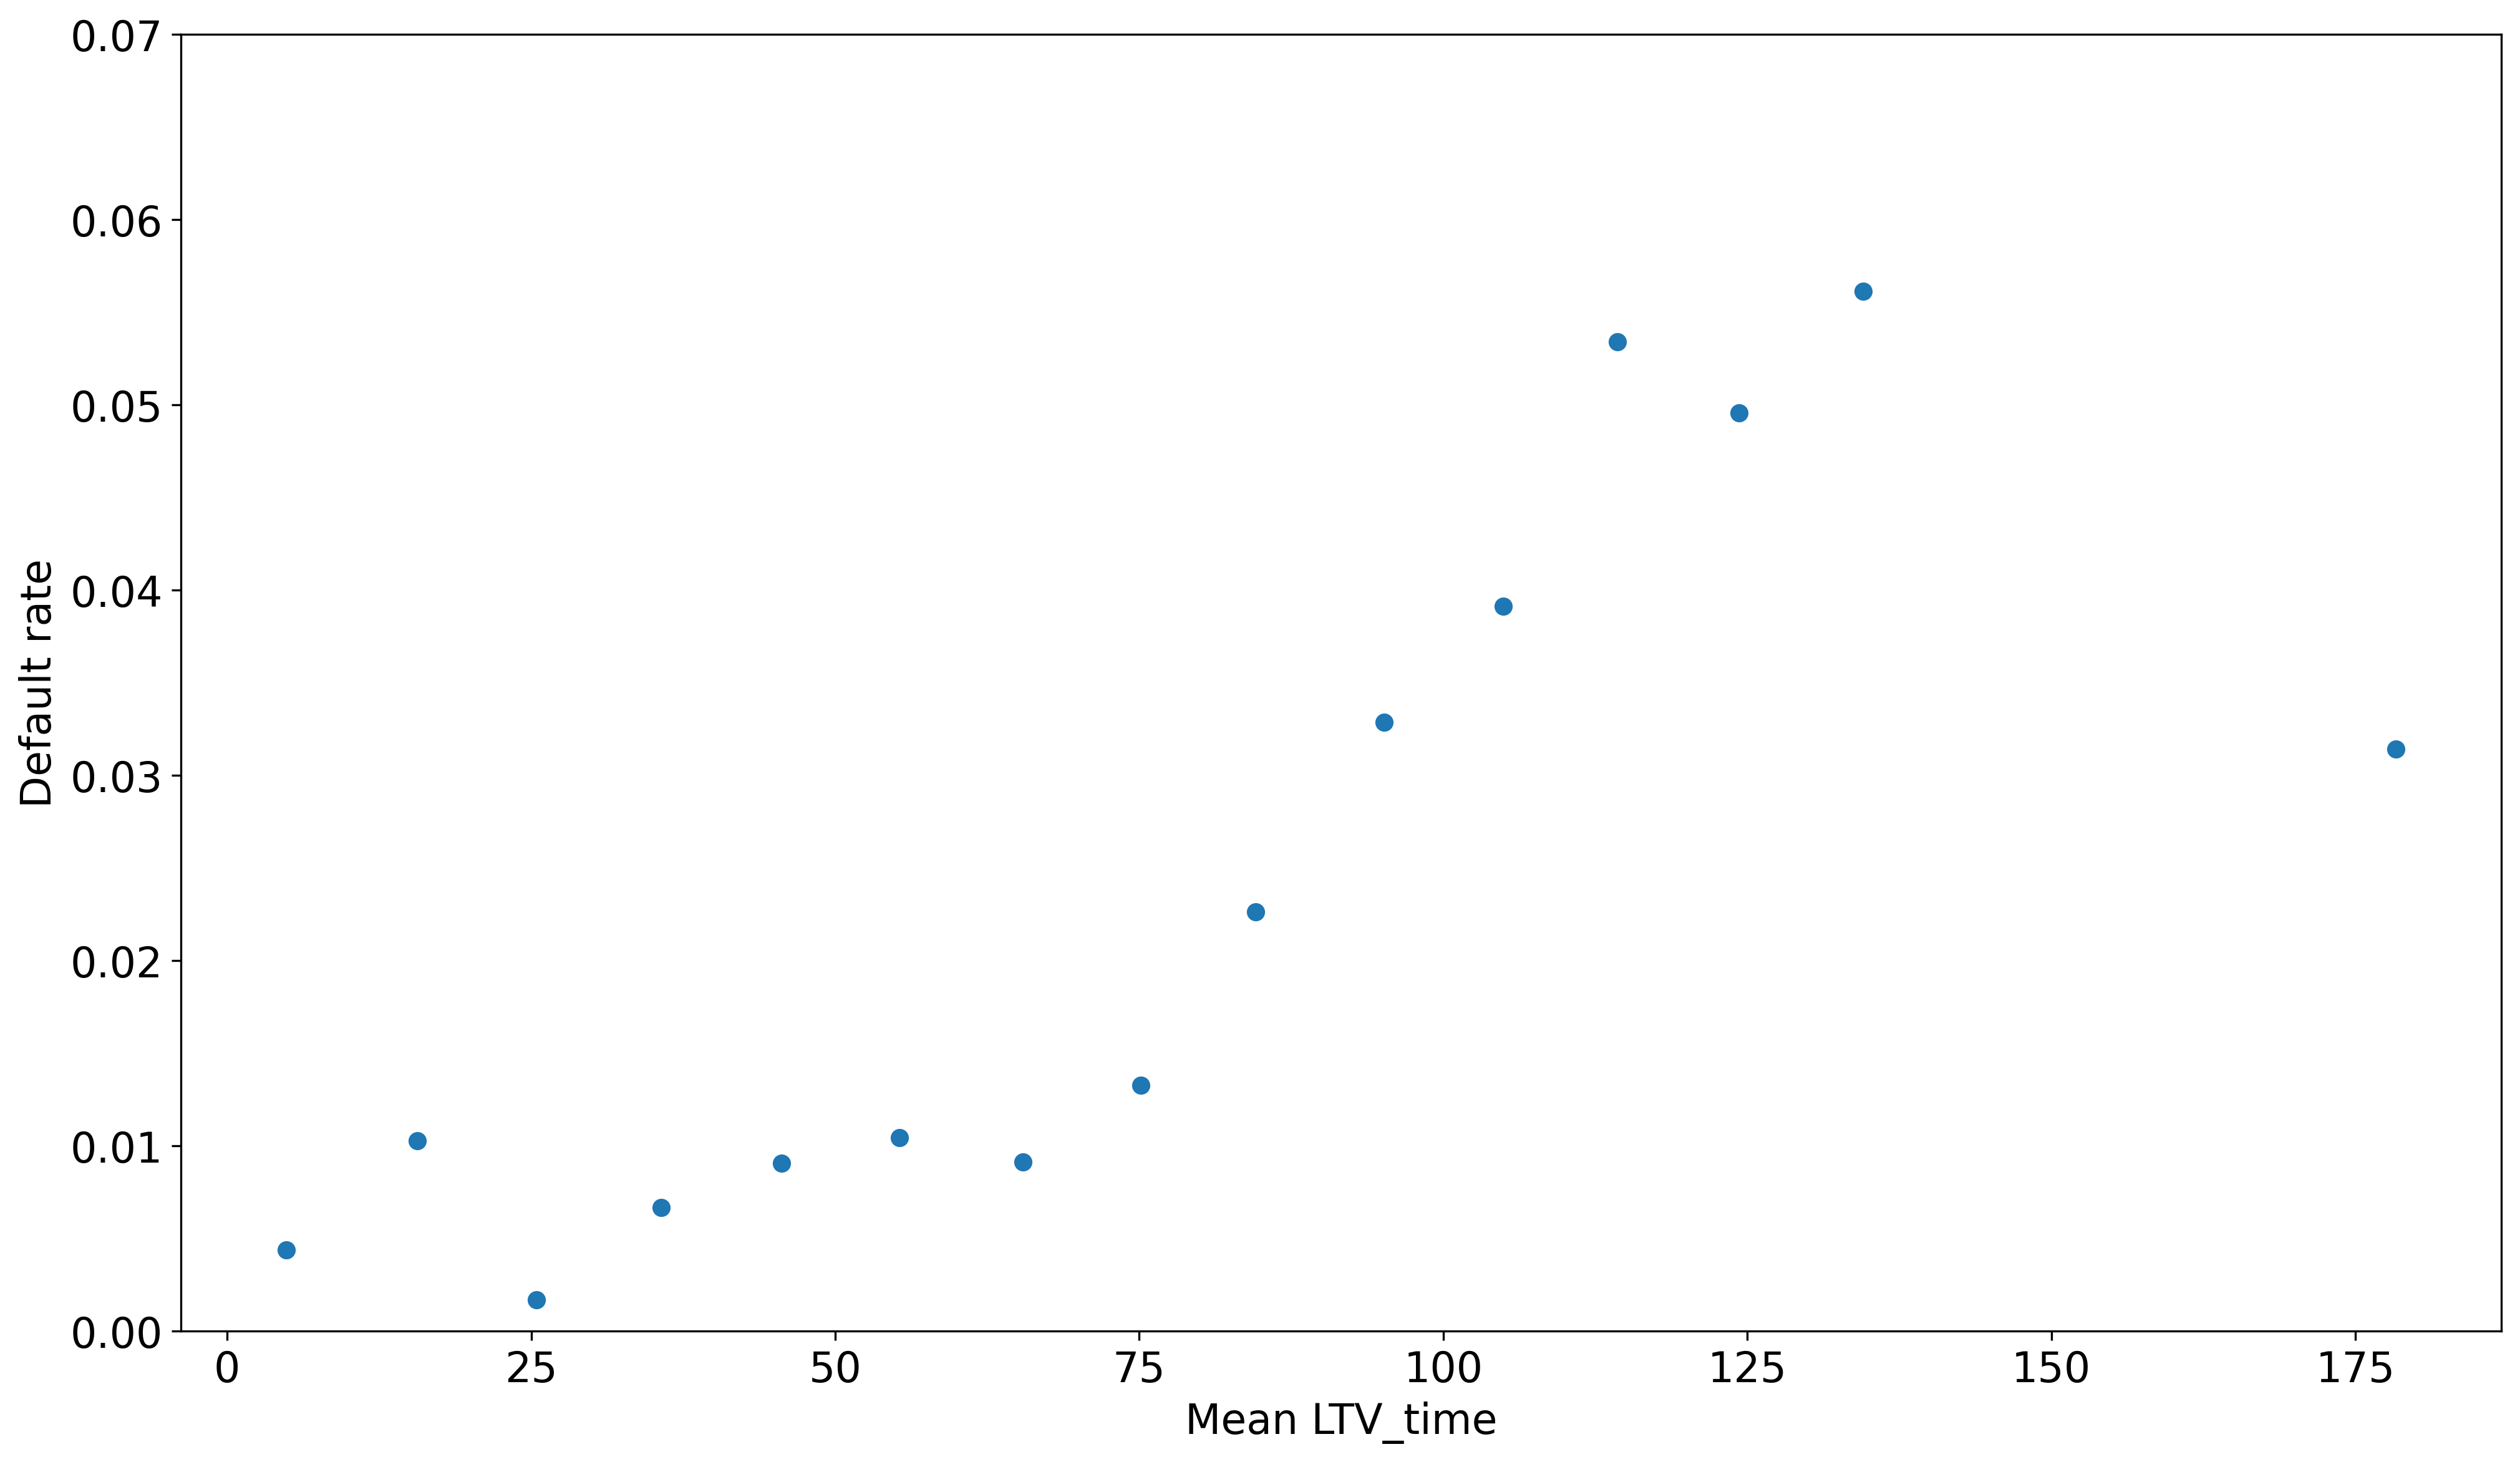

In [17]:
data = pd.read_csv('dcr.csv')  
data.loc[:,'LTV_time_cat'] = 0  
data.loc[data['LTV_time'] >= 10, 'LTV_time_cat'] = 1  
data.loc[data['LTV_time'] >= 20, 'LTV_time_cat'] = 2  
data.loc[data['LTV_time'] >= 30, 'LTV_time_cat'] = 3  
data.loc[data['LTV_time'] >= 40, 'LTV_time_cat'] = 4  
data.loc[data['LTV_time'] >= 50, 'LTV_time_cat'] = 5  
data.loc[data['LTV_time'] >= 60, 'LTV_time_cat'] = 6  
data.loc[data['LTV_time'] >= 70, 'LTV_time_cat'] = 7  
data.loc[data['LTV_time'] >= 80, 'LTV_time_cat'] = 8  
data.loc[data['LTV_time'] >= 90, 'LTV_time_cat'] = 9  
data.loc[data['LTV_time'] >= 100, 'LTV_time_cat'] = 10  
data.loc[data['LTV_time'] >= 110, 'LTV_time_cat'] = 11  
data.loc[data['LTV_time'] >= 120, 'LTV_time_cat'] = 12  
data.loc[data['LTV_time'] >= 130, 'LTV_time_cat'] = 13  
data.loc[data['LTV_time'] >= 140, 'LTV_time_cat'] = 14  
LTV_time_cat_means = data.groupby('LTV_time_cat')[['LTV_time', 'default_time']].mean()  
plt.scatter('LTV_time', 'default_time', data=LTV_time_cat_means)  
plt.ylabel('Default rate')  
plt.xlabel('Mean LTV_time')  
plt.ylim([0, 0.07])  
plt.show() 

In [18]:
data.loc[:,'LTV_time_p1'] = data.loc[:,'LTV_time']**1  
data.loc[:,'LTV_time_p2'] = data.loc[:,'LTV_time']**2  
data.loc[:,'LTV_time_p3'] = data.loc[:,'LTV_time']**3

In [19]:
data.loc[:,'LTV_time_sr1'] = data.loc[:,'LTV_time']  
data.loc[:,'LTV_time_sr2'] = 0  
data.loc[:,'LTV_time_sr3'] = 0  
data.loc[:,'LTV_time_80'] = data.loc[:,'LTV_time']-80  
data.loc[:,'LTV_time_120'] = data.loc[:,'LTV_time']-120  

data.loc[data['LTV_time'] > 80, 'LTV_time_sr2'] = data.loc[:,'LTV_time_80']  
data.loc[data['LTV_time'] > 120, 'LTV_time_sr3'] = data.loc[:,'LTV_time_120']

In [20]:
data2 = data[['LTV_time_sr1', 'LTV_time_sr2', 'LTV_time_sr3']]  
print(data2.describe().round(decimals=2))

       LTV_time_sr1  LTV_time_sr2  LTV_time_sr3
count      62153.00      62178.00      62178.00
mean          83.32         11.64          0.84
std           28.11         20.34         13.31
min            0.00          0.00          0.00
25%           67.06          0.00          0.00
50%           82.26          2.24          0.00
75%          100.77         20.76          0.00
max          803.51        723.51        683.51


In [21]:
data.loc[:,'LTV_time_sa1'] = data.loc[:,'LTV_time']  
data.loc[:,'LTV_time_sa2'] = 80  
data.loc[:,'LTV_time_sa3'] = 120  
data.loc[data['LTV_time'] > 80, 'LTV_time_sa2'] = data.loc[:,'LTV_time']  
data.loc[data['LTV_time'] > 120, 'LTV_time_sa3'] = data.loc[:,'LTV_time'] 


In [22]:
data2 = data[['LTV_time_sa1', 'LTV_time_sa2', 'LTV_time_sa3']]  
print(data2.describe().round(decimals=2))

       LTV_time_sa1  LTV_time_sa2  LTV_time_sa3
count      62153.00      62178.00      62178.00
mean          83.32         91.64        120.84
std           28.11         20.34         13.31
min            0.00         80.00        120.00
25%           67.06         80.00        120.00
50%           82.26         82.24        120.00
75%          100.77        100.76        120.00
max          803.51        803.51        803.51


In [23]:
data.loc[:,'LTV_time_d1'] = 0  
data.loc[:,'LTV_time_d2'] = 0  
data.loc[:,'LTV_time_d3'] = 0  
data.loc[:,'LTV_time_d4'] = 0  
data.loc[:,'LTV_time_d5'] = 0  
data.loc[:,'LTV_time_d6'] = 0  
data.loc[:,'LTV_time_d7'] = 0  
data.loc[:,'LTV_time_d8'] = 0  
data.loc[:,'LTV_time_d9'] = 0  
data.loc[:,'LTV_time_d10'] = 0  
data.loc[:,'LTV_time_d11'] = 0  
data.loc[:,'LTV_time_d12'] = 0  
data.loc[:,'LTV_time_d13'] = 0  
data.loc[:,'LTV_time_d14'] = 0  

data.loc[data['LTV_time_cat'] == 1, 'LTV_time_d1'] = 1  
data.loc[data['LTV_time_cat'] == 2, 'LTV_time_d2'] = 1  
data.loc[data['LTV_time_cat'] == 3, 'LTV_time_d3'] = 1  
data.loc[data['LTV_time_cat'] == 4, 'LTV_time_d4'] = 1  
data.loc[data['LTV_time_cat'] == 5, 'LTV_time_d5'] = 1  
data.loc[data['LTV_time_cat'] == 6, 'LTV_time_d6'] = 1  
data.loc[data['LTV_time_cat'] == 7, 'LTV_time_d7'] = 1  
data.loc[data['LTV_time_cat'] == 8, 'LTV_time_d8'] = 1  
data.loc[data['LTV_time_cat'] == 9, 'LTV_time_d9'] = 1  
data.loc[data['LTV_time_cat'] == 10, 'LTV_time_d10'] = 1  
data.loc[data['LTV_time_cat'] == 11, 'LTV_time_d11'] = 1  
data.loc[data['LTV_time_cat'] == 12, 'LTV_time_d12'] = 1  
data.loc[data['LTV_time_cat'] == 13, 'LTV_time_d13'] = 1  
data.loc[data['LTV_time_cat'] == 14, 'LTV_time_d14'] = 1 


In [25]:
table = pd.crosstab(data.LTV_time_cat, data.default_time, margins= True)  
table = table.drop(['All'], axis=0)  
table = table.rename(columns={1: 'deft', 0: 'nondeft'}).reset_index(drop=False)  
table.loc[:,'fracdeft'] = table.loc[:,'deft']/np.sum(table.loc[:,'deft'])  
table.loc[:,'fracnondeft'] = table.loc[:,'nondeft']/np.sum(table.loc[:,'nondeft'])  
table.loc[:,'LTV_time_WOE'] = np.log(table.loc[:,'fracdeft']/table.loc[:,'fracnondeft'])
print(table[['LTV_time_cat', 'fracdeft', 'fracnondeft', 'LTV_time_WOE']].round(decimals=2))

default_time  LTV_time_cat  fracdeft  fracnondeft  LTV_time_WOE
0                        0      0.00         0.00         -1.75
1                        1      0.00         0.00         -0.88
2                        2      0.00         0.01         -2.70
3                        3      0.01         0.02         -1.32
4                        4      0.02         0.05         -1.01
..                     ...       ...          ...           ...
10                      10      0.18         0.11          0.48
11                      11      0.20         0.09          0.81
12                      12      0.07         0.03          0.73
13                      13      0.03         0.01          0.86
14                      14      0.01         0.01          0.26

[15 rows x 4 columns]


In [26]:
table2 = table[['LTV_time_cat', 'LTV_time_WOE']]  
data = pd.merge(data, table2, on='LTV_time_cat')

In [32]:
option1 = smf.glm(data=data, formula='default_time ~ LTV_time_p1 + LTV_time_p2 +  LTV_time_p3', family=sm.families.Binomial()).fit()  
option2 = smf.glm(data=data, formula='default_time ~ LTV_time_sa1 + LTV_time_sa2 +  LTV_time_sa3', family=sm.families.Binomial()).fit()  

data.loc[:,'LTV_time_cat'] = pd.Categorical(data.LTV_time_cat, ordered=False)  

option3 = smf.glm(data=data, formula='default_time ~ LTV_time_cat', family=sm.families.Binomial()).fit()  
option4 = smf.glm(data=data, formula='default_time ~ LTV_time_WOE', family=sm.families.  Binomial()).fit()

In [33]:
option1 = pd.DataFrame(option1.predict(data), columns = ['option1'])  
option2 = pd.DataFrame(option2.predict(data), columns = ['option2'])  
option3 = pd.DataFrame(option3.predict(data), columns = ['option3'])  
option4 = pd.DataFrame(option4.predict(data), columns = ['option4'])  

data2 = pd.concat([data.default_time, data.LTV_time_cat, data.LTV_time, option1, option2,  option3, option4], axis=1) 

data_means = data2.groupby('LTV_time_cat')[['default_time', 'LTV_time', 'option1', 'option2', 'option3', 'option4']].mean()

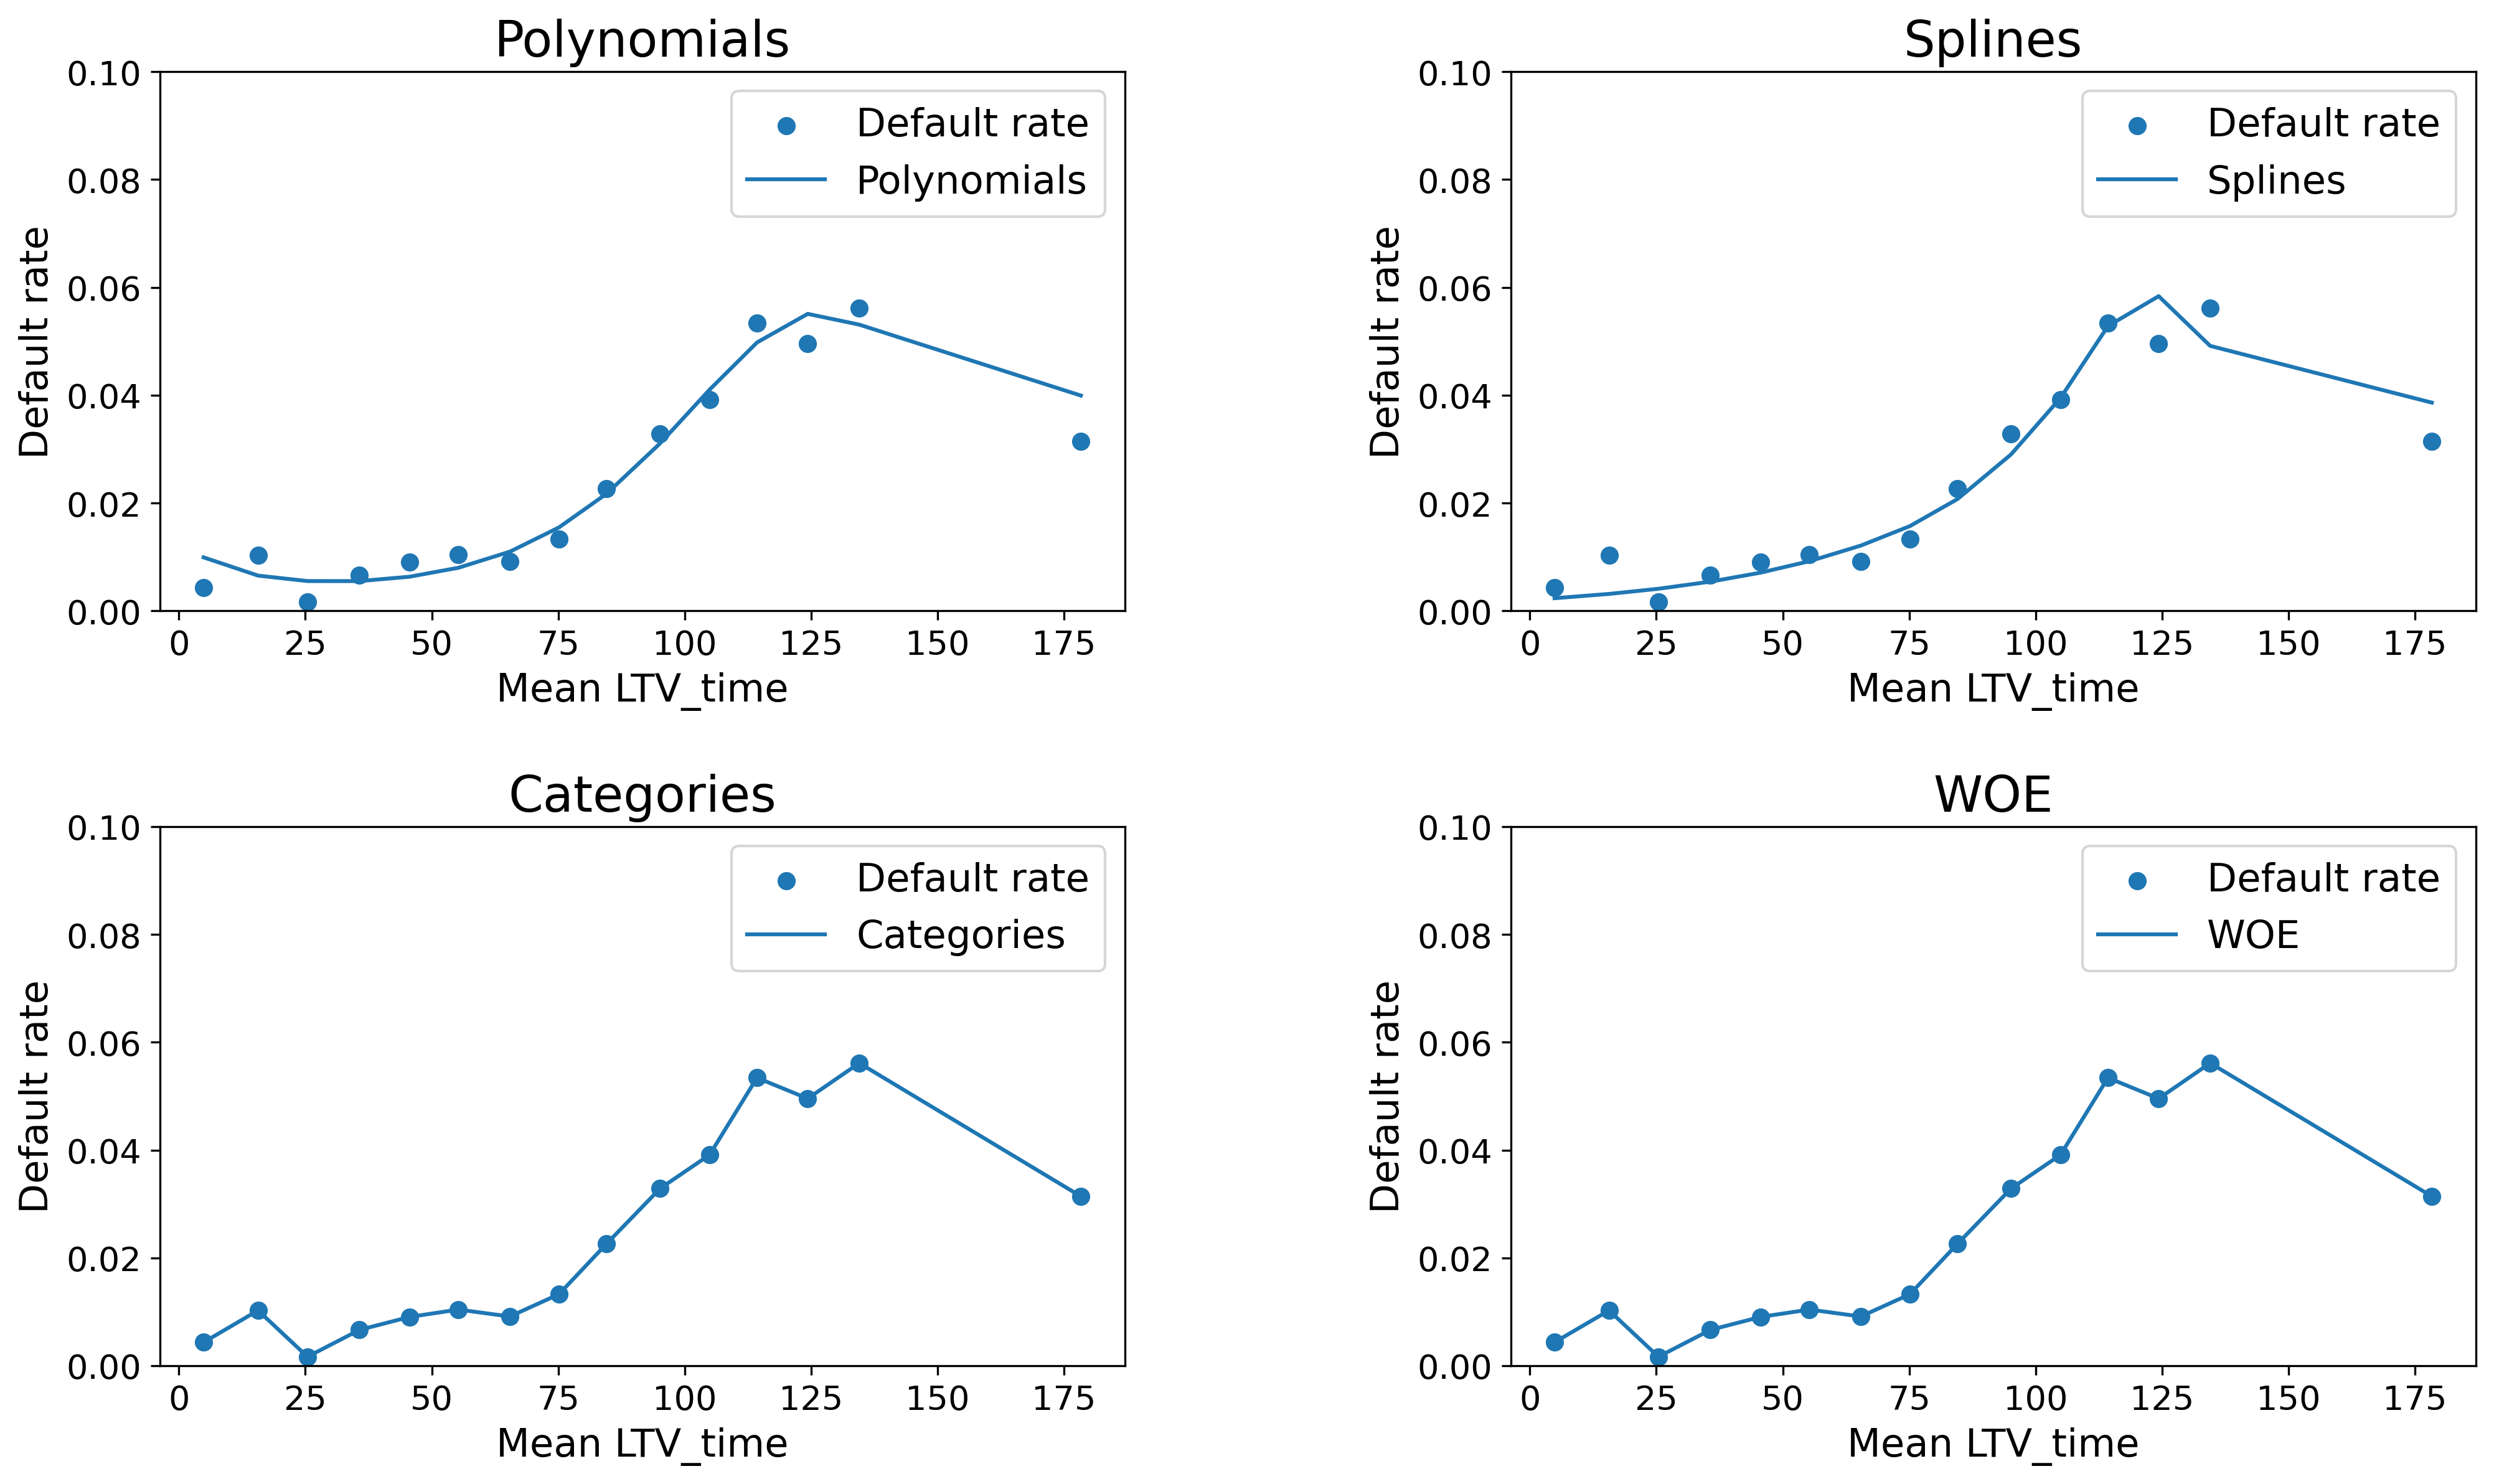

In [34]:
plt.subplots_adjust(hspace=0.4, wspace=0.4)  

plt.subplot(221)  
plt.title('Polynomials')  
plt.scatter('LTV_time', 'default_time', data=data_means, label='Default rate')  
plt.plot('LTV_time', 'option1', data=data_means, label='Polynomials')  
plt.ylabel('Default rate', fontsize=15)  
plt.xlabel('Mean LTV_time', fontsize=15)  
plt.tick_params(axis='both', labelsize=13)  
plt.ylim([0, 0.10])  
plt.legend(loc='best', fontsize=15)  

plt.subplot(222)  
plt.title('Splines')  
plt.scatter('LTV_time', 'default_time', data=data_means, label='Default rate')  
plt.plot('LTV_time', 'option2', data=data_means, label='Splines')  
plt.ylabel('Default rate', fontsize=15)  
plt.xlabel('Mean LTV_time', fontsize=15)  
plt.tick_params(axis='both', labelsize=13)  
plt.ylim([0, 0.10])  
plt.legend(loc='best', fontsize=15)  

plt.subplot(223)  
plt.title('Categories')  
plt.scatter('LTV_time', 'default_time', data=data_means, label='Default rate')  
plt.plot('LTV_time', 'option3', data=data_means, label='Categories')  
plt.ylabel('Default rate', fontsize=15)  
plt.xlabel('Mean LTV_time', fontsize=15)  
plt.tick_params(axis='both', labelsize=13)  
plt.ylim([0, 0.10])  
plt.legend(loc='best', fontsize=15)  

plt.subplot(224)  
plt.title('WOE')  
plt.scatter('LTV_time', 'default_time', data=data_means, label='Default rate')  
plt.plot('LTV_time', 'option4', data=data_means, label='WOE')  
plt.ylabel('Default rate', fontsize=15)  
plt.xlabel('Mean LTV_time', fontsize=15)  
plt.tick_params(axis='both', labelsize=13)  
plt.ylim([0, 0.10])  
plt.legend(loc='best', fontsize=15)  

plt.show() 

       FICO_orig_time
count        62178.00
mean           673.36
std             72.10
min            429.00
25%            628.00
50%            675.00
75%            730.00
max            819.00


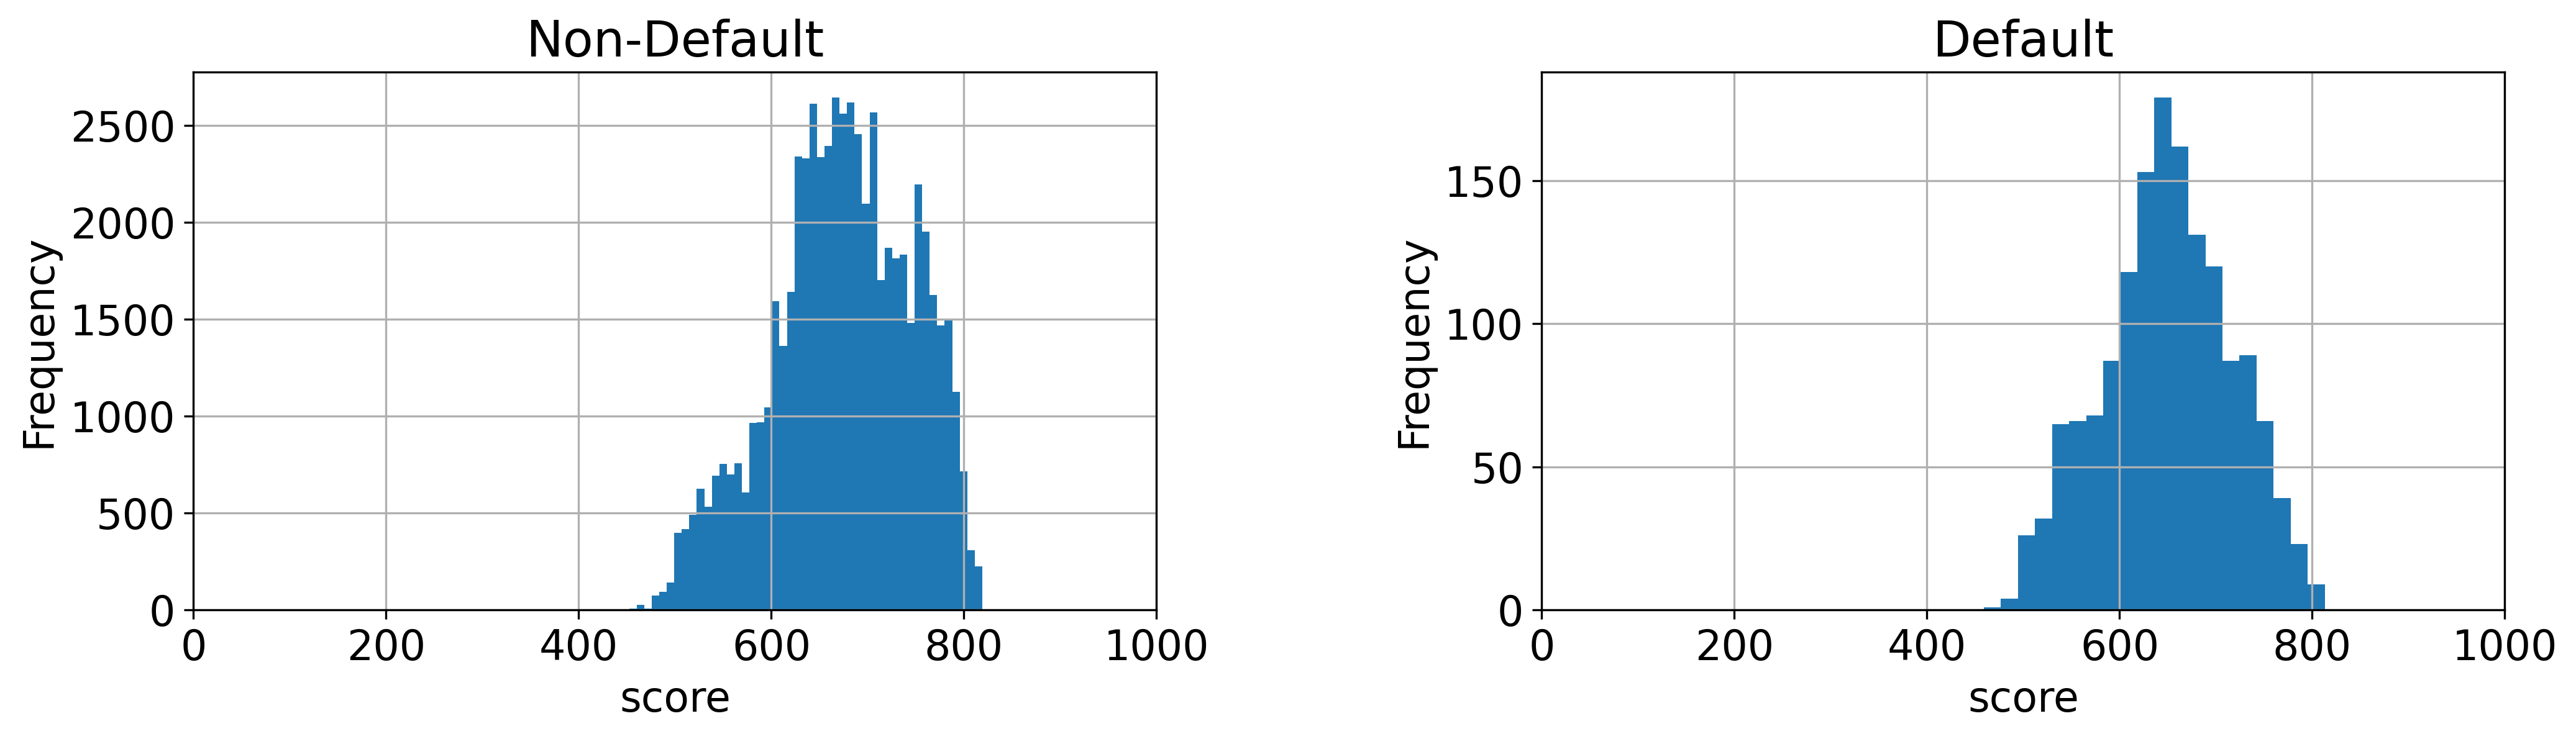

In [35]:
print(data[['FICO_orig_time']].describe().round(decimals=2))  

plt.subplots_adjust(hspace=0.4, wspace=0.4)  

plt.subplot(221)  
plt.title('Non-Default')  
data.loc[data['default_time']==0,'FICO_orig_time'].hist(bins=50)  
plt.xlabel('score')  
plt.ylabel('Frequency')  
plt.xlim(0,1000)  

plt.subplot(222)  
plt.title('Default')  
data.loc[data['default_time']==1,'FICO_orig_time'].hist(bins=20)  
plt.xlabel('score')  
plt.ylabel('Frequency')  
plt.xlim(0,1000)  

plt.show()

In [36]:
data_ols = smf.ols(formula='default_time ~ FICO_orig_time + LTV_time + gdp_time', data=data).fit()  
data['Intercept'] = 1  
X=data[['Intercept','FICO_orig_time','LTV_time','gdp_time']] 
score = pd.DataFrame(X.dot(data_ols.params),columns = ['score']) 

In [37]:
score = pd.DataFrame(data_ols.fittedvalues,columns = ['score'])

          score
count  62153.00
mean       0.02
std        0.02
min       -0.03
25%        0.01
50%        0.02
75%        0.03
max        0.28


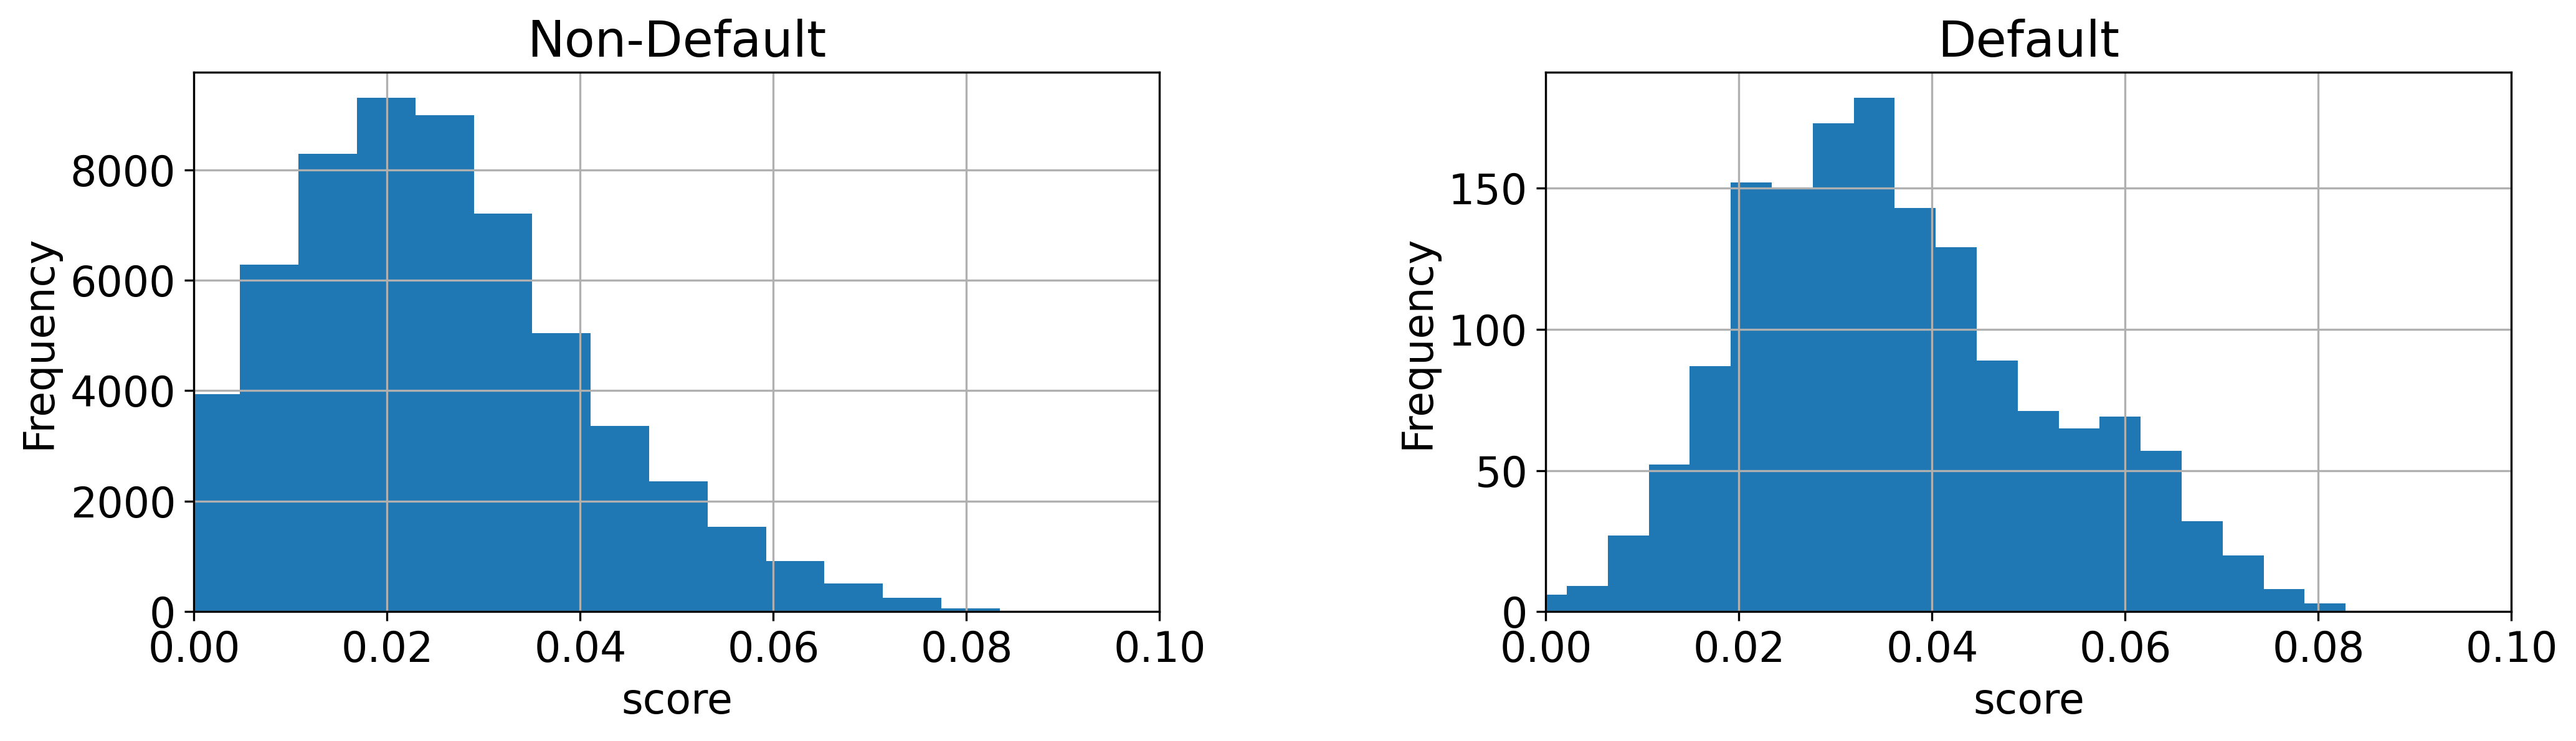

In [38]:
print(score.describe().round(decimals=2))  
plt.subplots_adjust(hspace=0.4, wspace=0.4)  

plt.subplot(221)  
plt.title('Non-Default')  
score.loc[data['default_time']==0,'score'].hist(bins=50)  
plt.xlabel('score')  
plt.ylabel('Frequency')  
plt.xlim(0,0.1) 

plt.subplot(222)  
plt.title('Default')  
score.loc[data['default_time']==1,'score'].hist(bins=20)  
plt.xlabel('score')  
plt.ylabel('Frequency')  
plt.xlim(0,0.1)  
plt.show() 

In [39]:
data1 = data.dropna(subset=['time', 'default_time','LTV_time', 'FICO_orig_time']).copy()

In [40]:
data1 = data1.loc[data['time']==60].copy()  
X_train = data1[['FICO_orig_time', 'LTV_time']] 
X_sample = X_train.sample(n=10, axis = 0, random_state=12345)  

scaler = StandardScaler().fit(X_sample)  
X_train_scaled = scaler.transform(X_sample)  
#Change LTV sign  
X_train_scaled[:,1]=-X_train_scaled[:,1] 
print(X_train_scaled.round(2)) 

[[-0.53  1.75]
 [-0.29 -0.04]
 [ 0.23 -0.97]
 [ 0.55 -0.55]
 [ 0.35  0.5 ]
 [-2.03 -0.06]
 [ 1.45  0.44]
 [-0.98  1.25]
 [ 1.4  -1.87]
 [-0.14 -0.45]]


In [41]:
kmeans = KMeans(n_clusters=3)  
kmeans.fit(X_train_scaled) 


KMeans(n_clusters=3)

In [44]:
KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,  n_clusters=3, n_init=10, random_state=None, tol=0.0001, verbose=0)


KMeans(algorithm='auto', n_clusters=3, n_init=10)

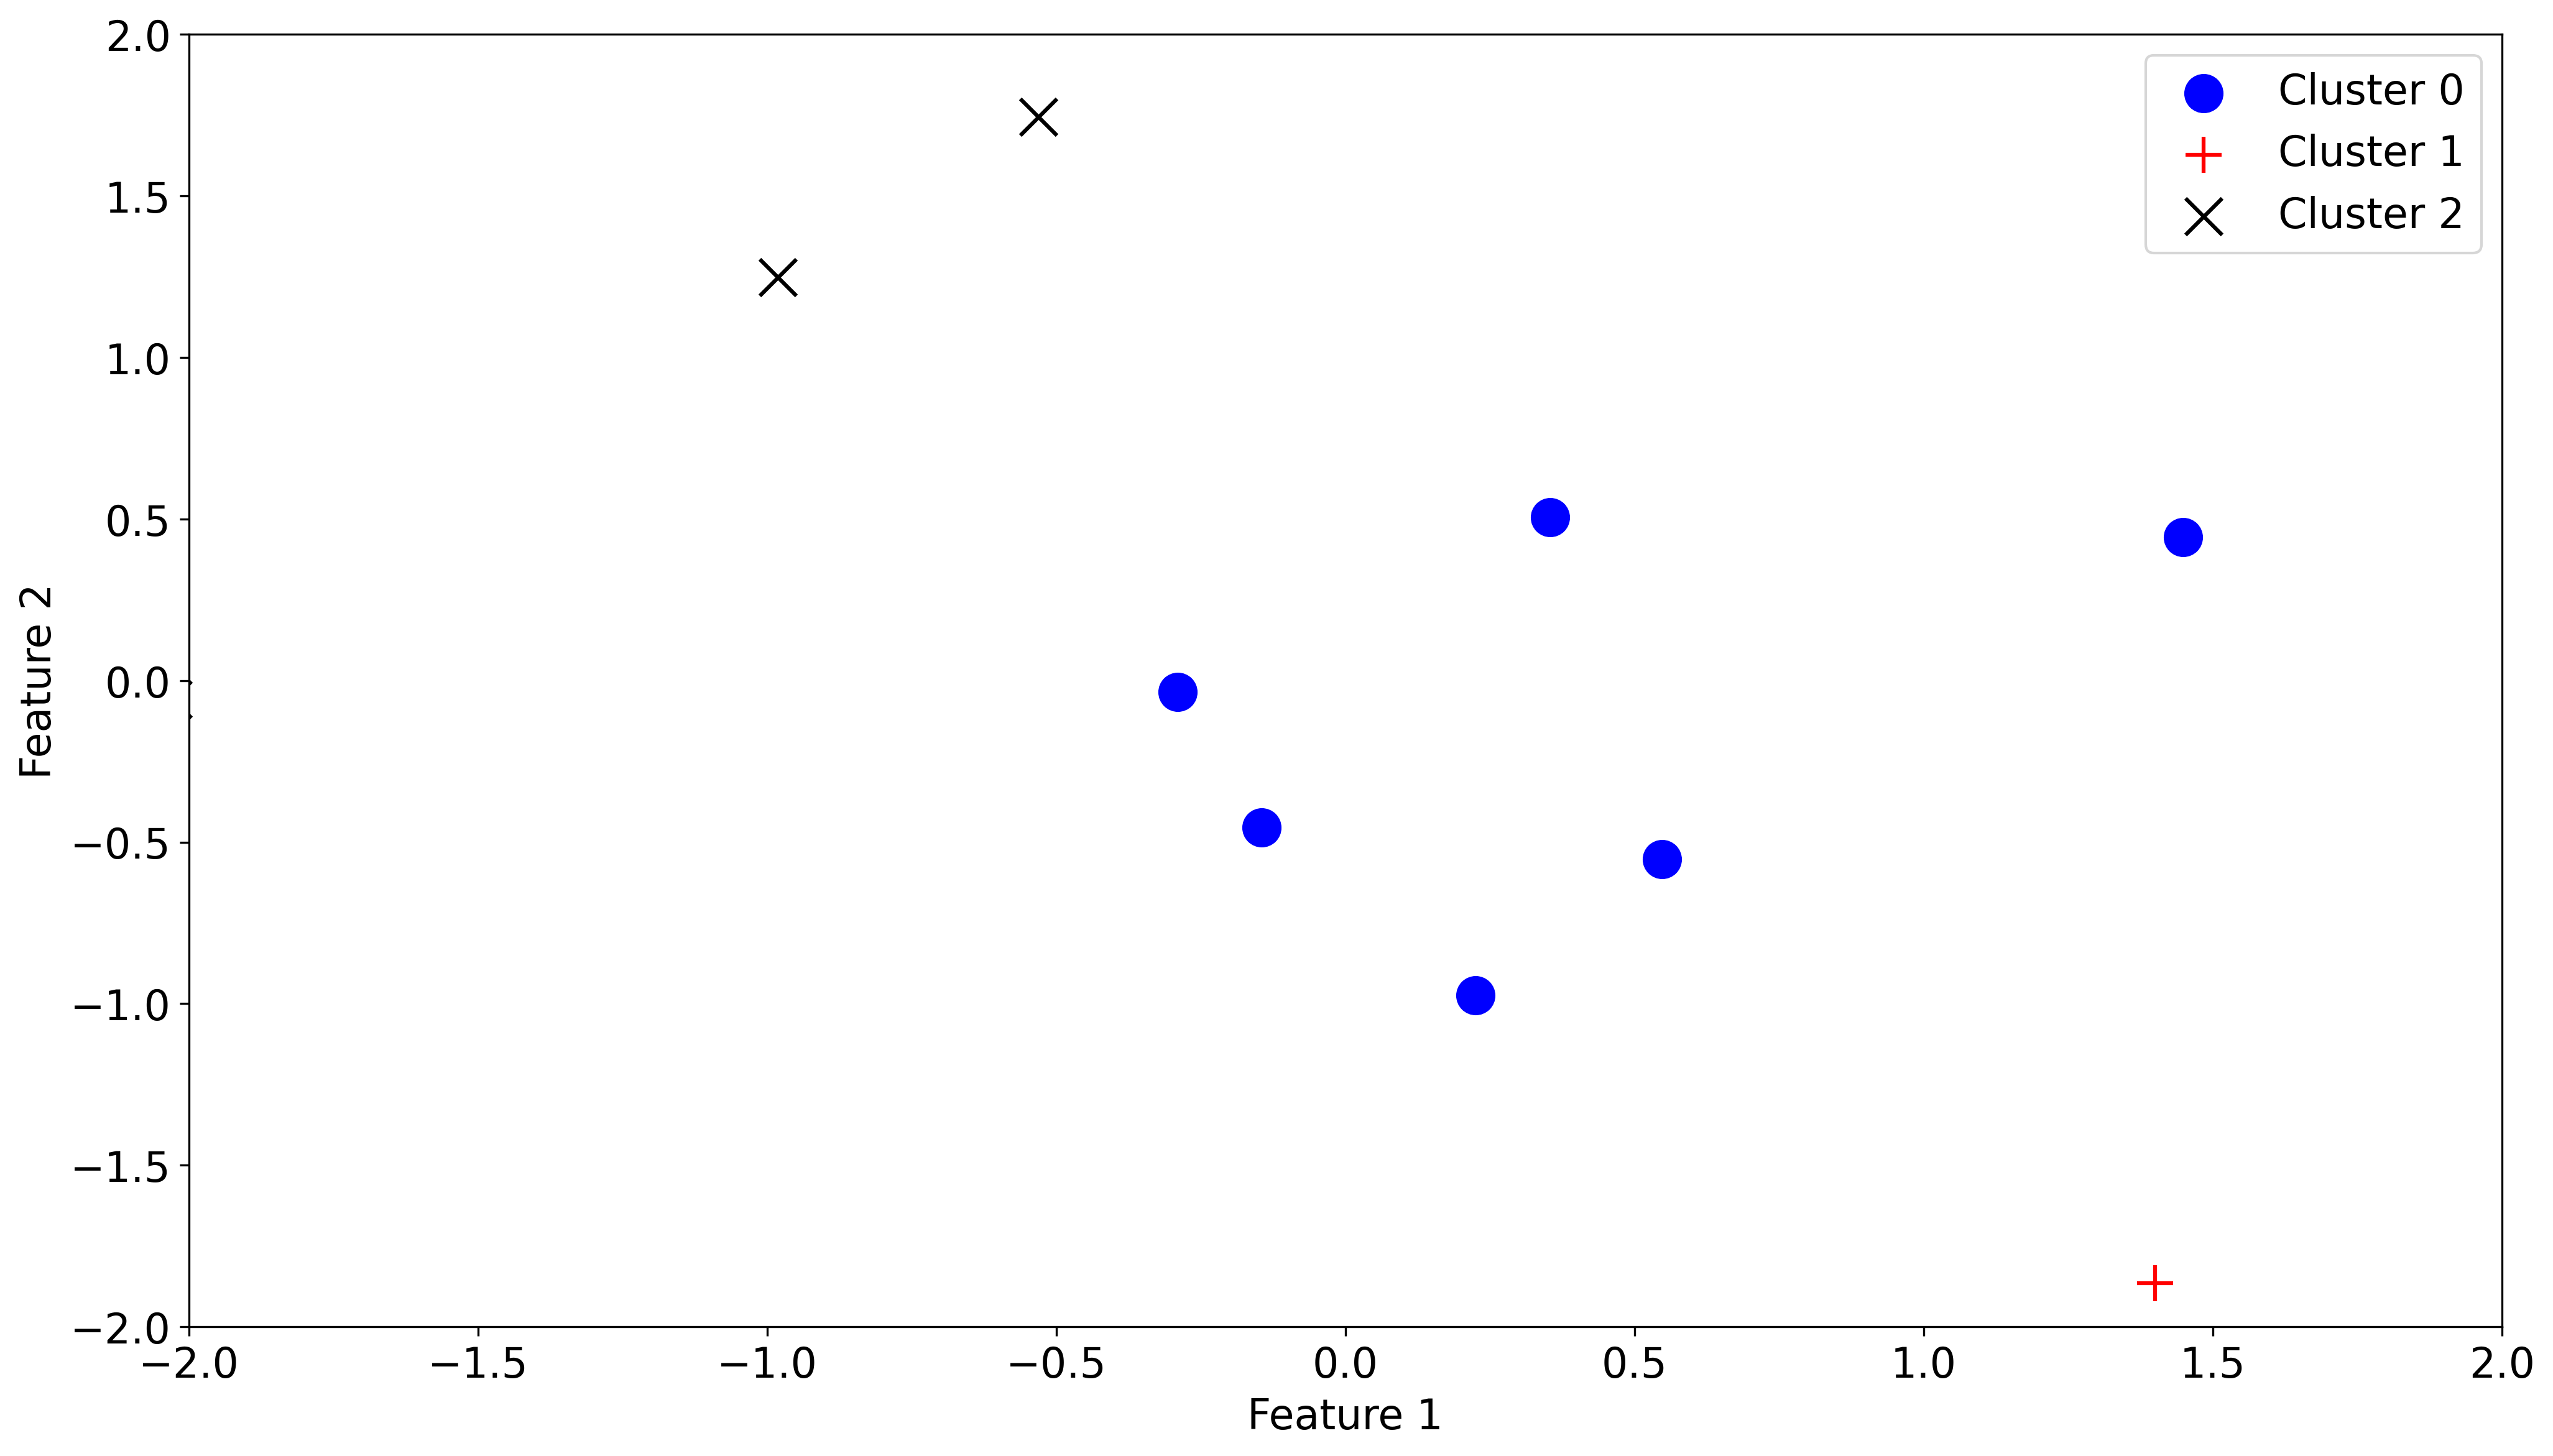

In [45]:
ref_0 = kmeans.labels_ == 0 
ref_1 = kmeans.labels_ == 1  
ref_2 = kmeans.labels_ == 2  

X_train_scaled_0 = X_train_scaled[ref_0,:]  
X_train_scaled_1 = X_train_scaled[ref_1,:]  
X_train_scaled_2 = X_train_scaled[ref_2,:]  

plt.scatter(X_train_scaled_0[:, 0], X_train_scaled_0[:, 1], c='blue', marker='o', s=200,  label='Cluster 0')  
plt.scatter(X_train_scaled_1[:, 0], X_train_scaled_1[:, 1], c='red', marker='+', s=200,  label='Cluster 1')  
plt.scatter(X_train_scaled_2[:, 0], X_train_scaled_2[:, 1], c='black', marker='x', s=200,  label='Cluster 2')  

plt.xlim(-2, 2)  
plt.ylim(-2, 2)  
plt.xlabel('Feature 1')  
plt.ylabel('Feature 2')  
plt.legend(loc='best')  

plt.show() 


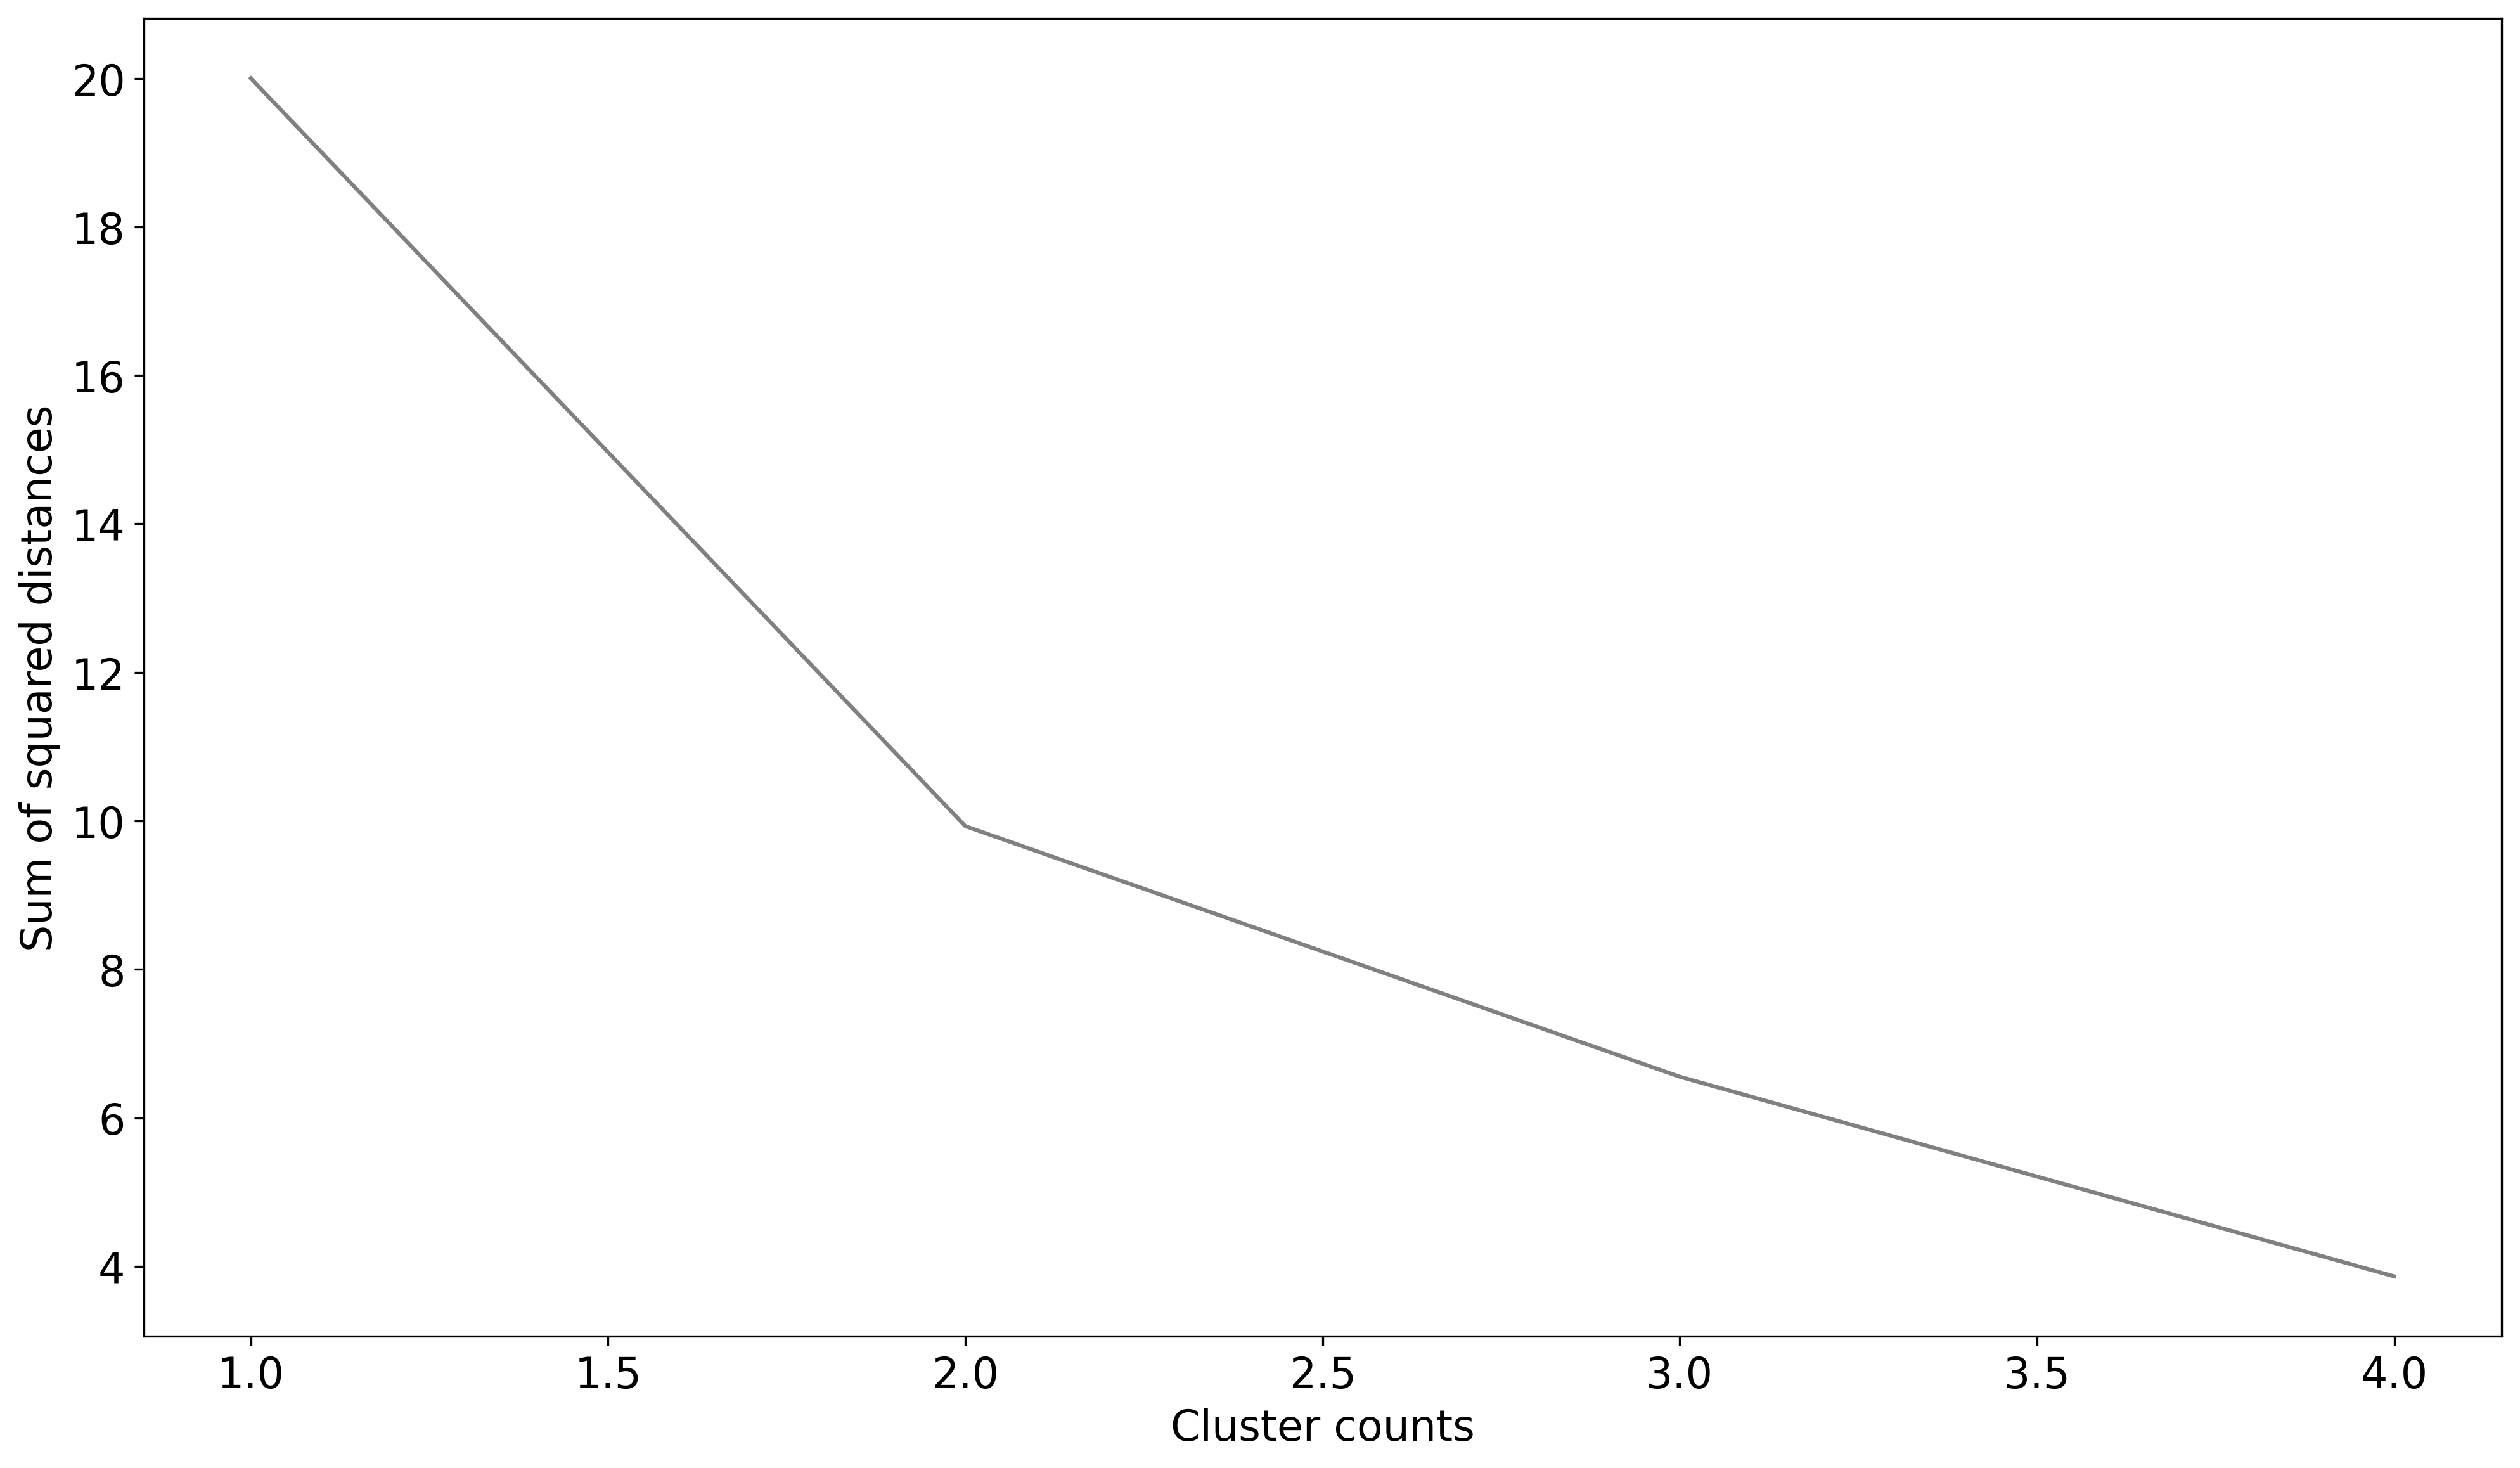

In [46]:
Nc = range(1, 5)  
kmeans_Nc = [KMeans(n_clusters=i) for i in Nc]  
score_Nc = [kmeans_Nc[i].fit(X_train_scaled).inertia_ for i in range(len(kmeans_Nc))]  

plt.plot(Nc, score_Nc, color='gray')  
plt.xlabel('Cluster counts')  
plt.ylabel('Sum of squared distances') 
plt.show() 

In [47]:
pdist_x = pdist(X_train_scaled)  
print(pdist_x.round(2)) 

[1.8  2.82 2.54 1.52 2.34 2.37 0.67 4.1  2.23 1.07 0.98 0.84 1.74 1.8
 1.46 2.49 0.44 0.53 1.48 2.43 1.87 2.53 1.47 0.64 1.07 2.62 1.34 2.36
 1.57 0.7  2.45 1.1  1.53 2.59 1.08 3.51 1.67 3.88 1.92 2.56 2.31 1.83
 3.92 1.9  2.09]


In [48]:
matrix = squareform(pdist_x)  
print(matrix.round(2)) 

[[0.   1.8  2.82 2.54 1.52 2.34 2.37 0.67 4.1  2.23]
 [1.8  0.   1.07 0.98 0.84 1.74 1.8  1.46 2.49 0.44]
 [2.82 1.07 0.   0.53 1.48 2.43 1.87 2.53 1.47 0.64]
 [2.54 0.98 0.53 0.   1.07 2.62 1.34 2.36 1.57 0.7 ]
 [1.52 0.84 1.48 1.07 0.   2.45 1.1  1.53 2.59 1.08]
 [2.34 1.74 2.43 2.62 2.45 0.   3.51 1.67 3.88 1.92]
 [2.37 1.8  1.87 1.34 1.1  3.51 0.   2.56 2.31 1.83]
 [0.67 1.46 2.53 2.36 1.53 1.67 2.56 0.   3.92 1.9 ]
 [4.1  2.49 1.47 1.57 2.59 3.88 2.31 3.92 0.   2.09]
 [2.23 0.44 0.64 0.7  1.08 1.92 1.83 1.9  2.09 0.  ]]


[[ 1.    9.    0.44  2.  ]
 [ 2.    3.    0.53  2.  ]
 [10.   11.    0.64  4.  ]
 [ 0.    7.    0.67  2.  ]
 [ 4.   12.    0.84  5.  ]
 [ 6.   14.    1.1   6.  ]
 [13.   15.    1.46  8.  ]
 [ 8.   16.    1.47  9.  ]
 [ 5.   17.    1.67 10.  ]]


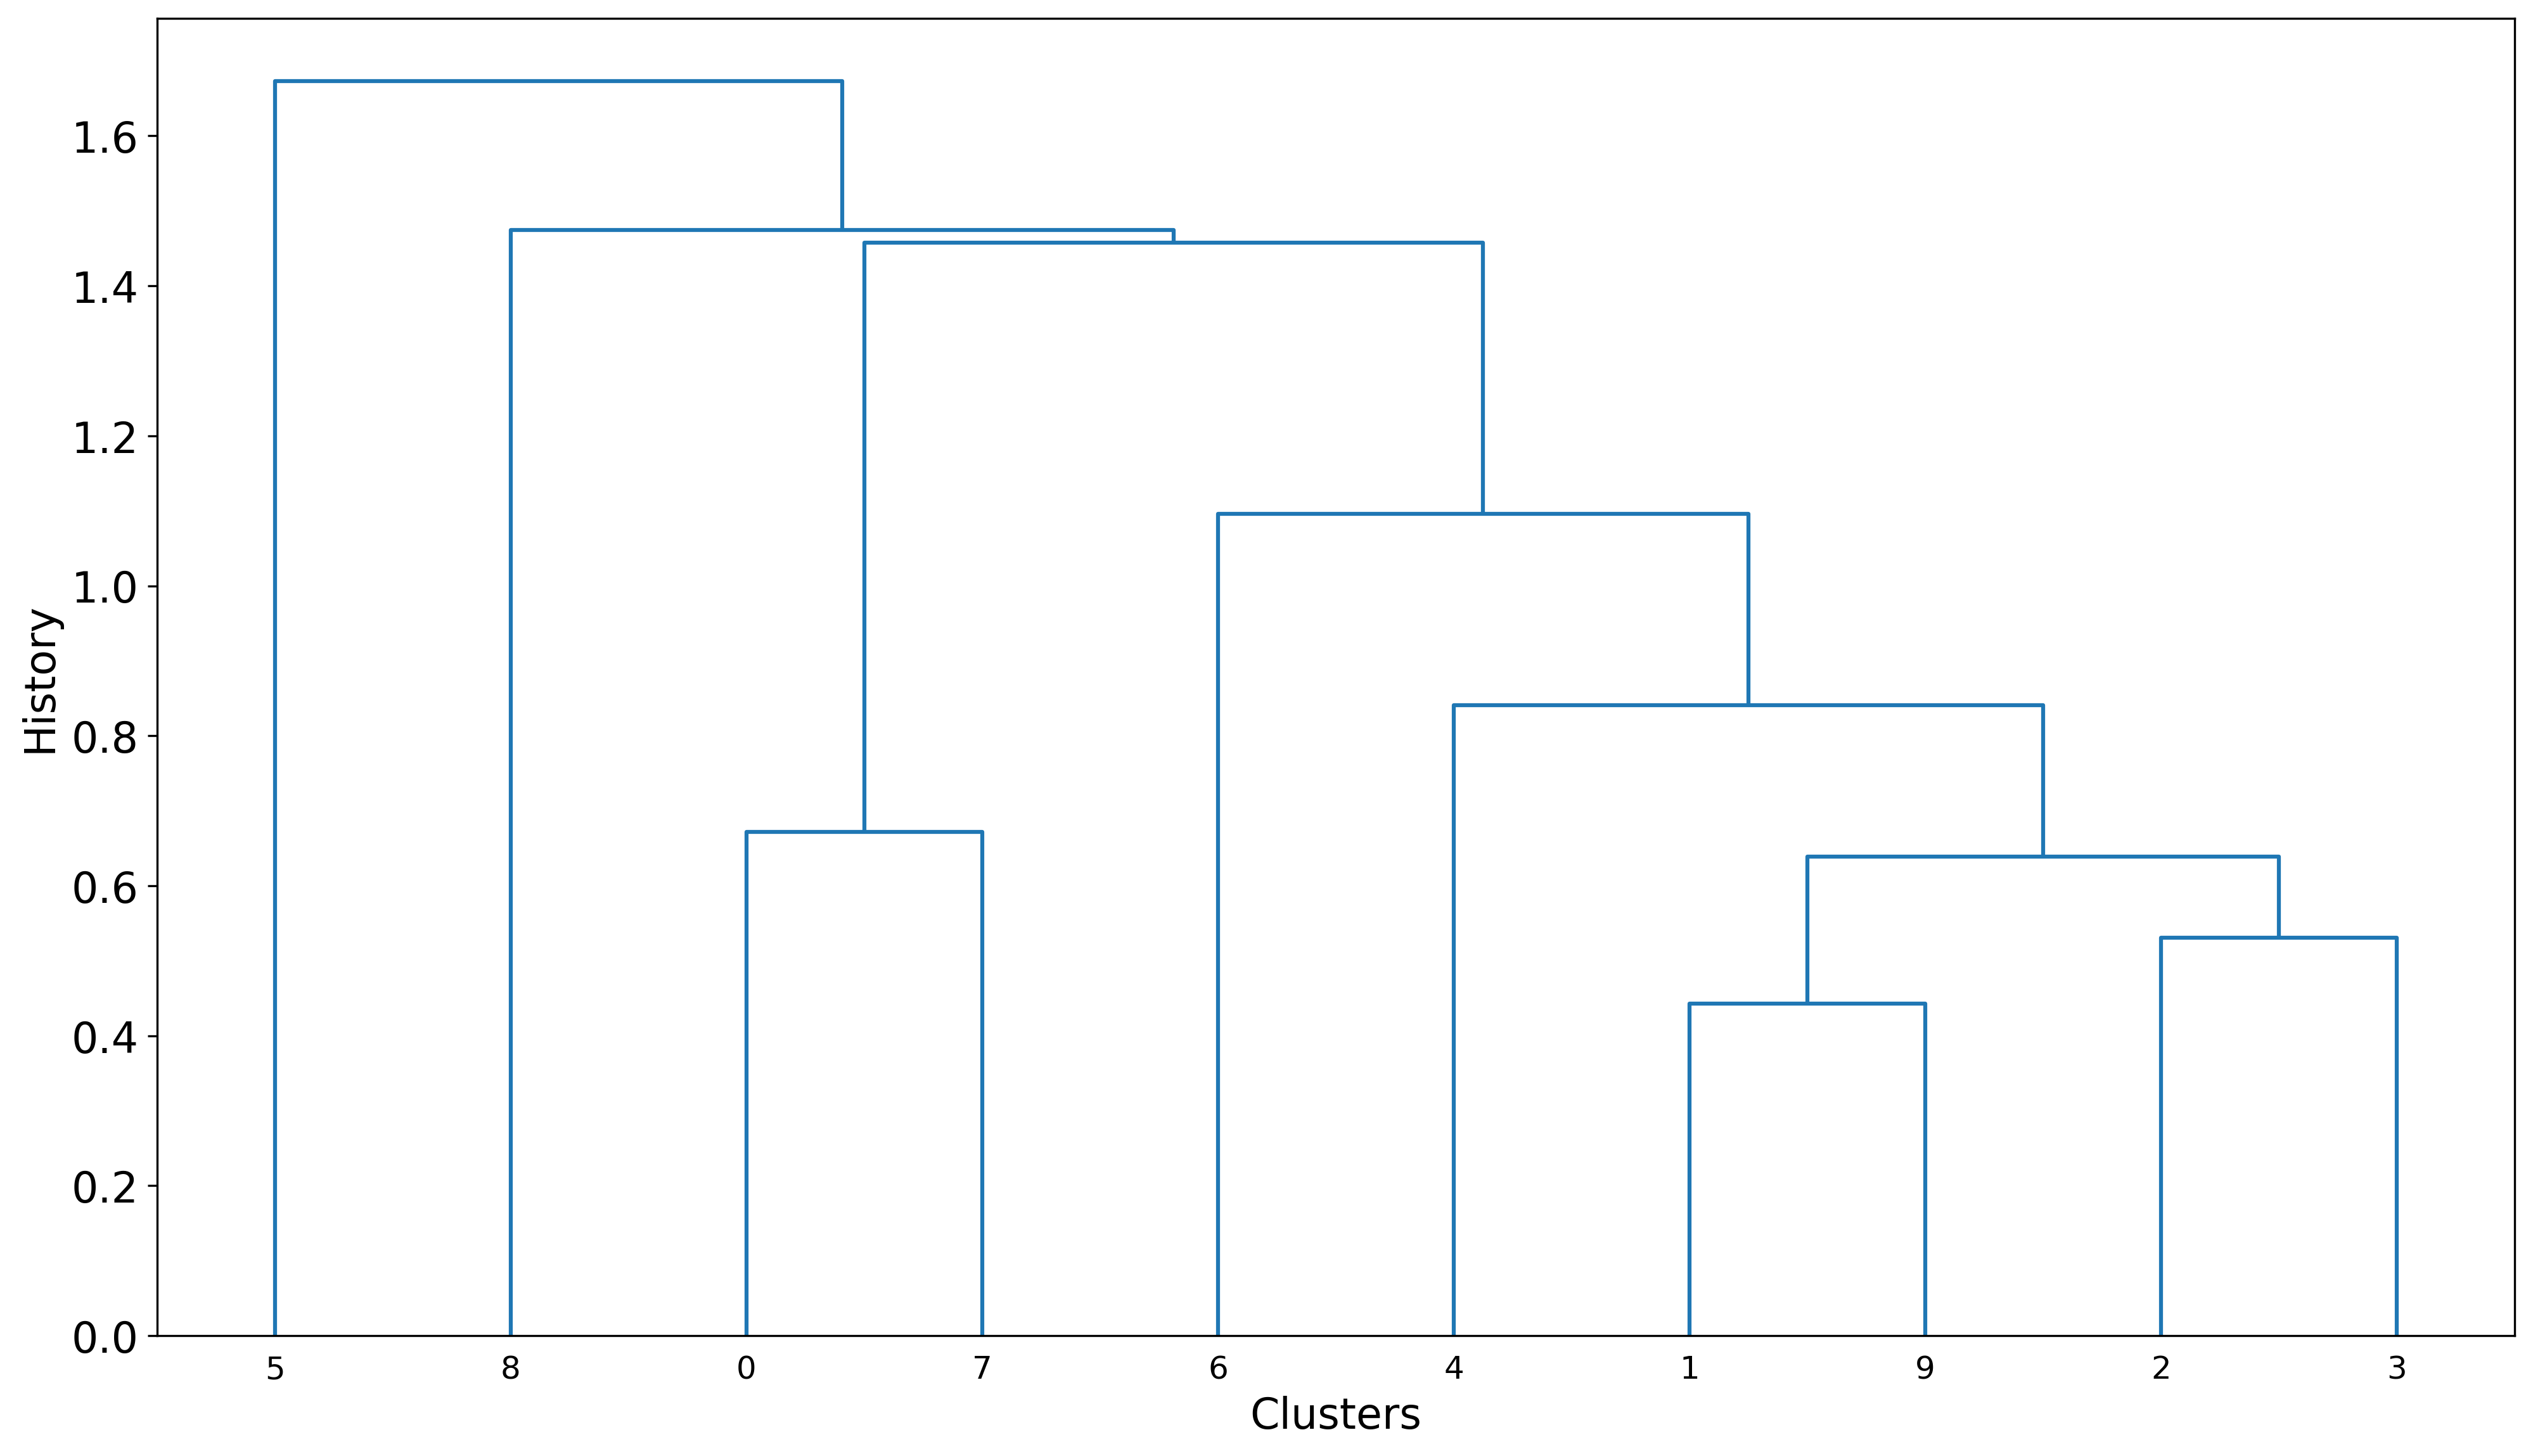

In [49]:
plt.figure()  
plt.xticks(fontsize = 50)  
Z = shc.linkage(X_train_scaled, method='single')  

print(Z.round(2))  
D_s = shc.dendrogram(Z,color_threshold=0.2,  no_labels=False)  
agglo_s = AgglomerativeClustering(n_clusters=3, linkage='single')  
agglo_s.fit(X_train_scaled)  

plt.xlabel('Clusters')  
plt.ylabel('History')  
plt.show() 


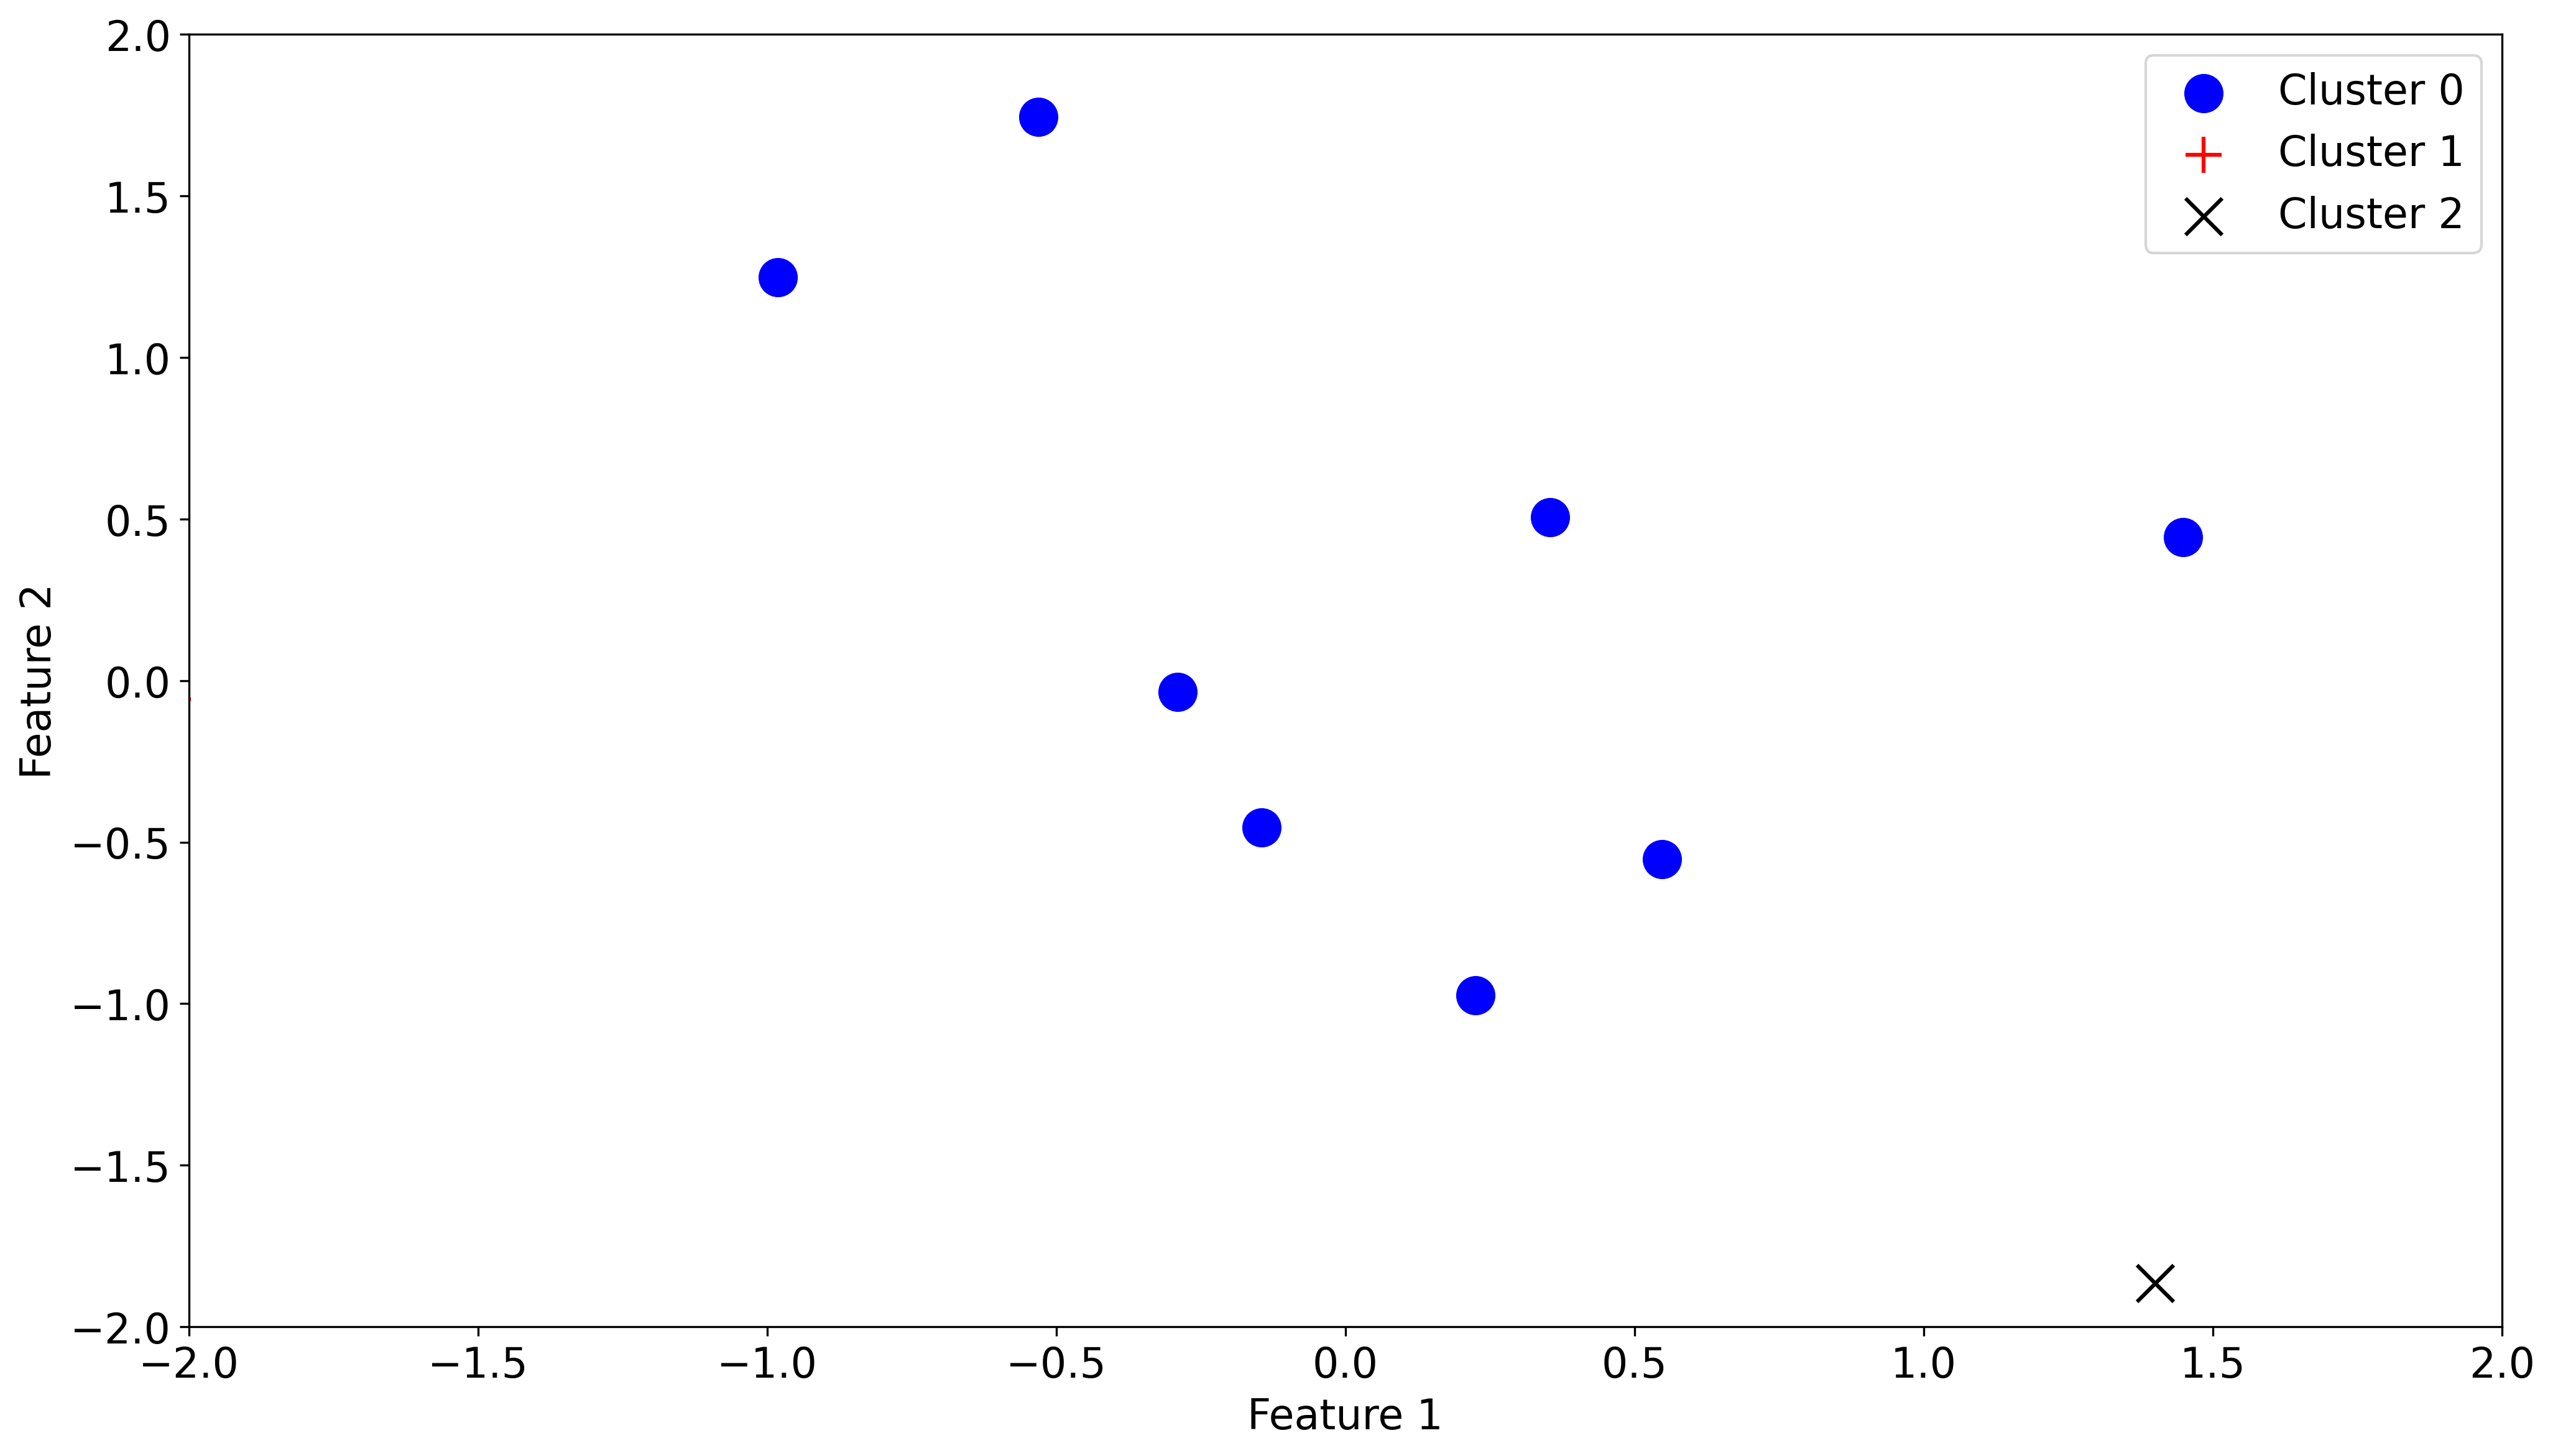

In [50]:
ref_0 = agglo_s.labels_ == 0  
ref_1 = agglo_s.labels_ == 1  
ref_2 = agglo_s.labels_ == 2  

X_train_scaled_0 = X_train_scaled[ref_0,:]  
X_train_scaled_1 = X_train_scaled[ref_1,:]  
X_train_scaled_2 = X_train_scaled[ref_2,:]  

plt.scatter(X_train_scaled_0[:, 0], X_train_scaled_0[:, 1], c='blue', marker='o', s=200,  label='Cluster 0') 
plt.scatter(X_train_scaled_1[:, 0], X_train_scaled_1[:, 1], c='red', marker='+', s=200,  label='Cluster 1') 
plt.scatter(X_train_scaled_2[:, 0], X_train_scaled_2[:, 1], c='black', marker='x', s=200,  label='Cluster 2')  

plt.xlim(-2, 2) 
plt.ylim(-2, 2) 
plt.xlabel('Feature 1')  
plt.ylabel('Feature 2')  
plt.legend(loc='best')  

plt.show() 


[[ 1.    9.    0.44  2.  ]
 [ 2.    3.    0.53  2.  ]
 [ 0.    7.    0.67  2.  ]
 [10.   11.    1.07  4.  ]
 [ 4.    6.    1.1   2.  ]
 [13.   14.    1.87  6.  ]
 [ 5.   12.    2.34  3.  ]
 [ 8.   15.    2.59  7.  ]
 [16.   17.    4.1  10.  ]]


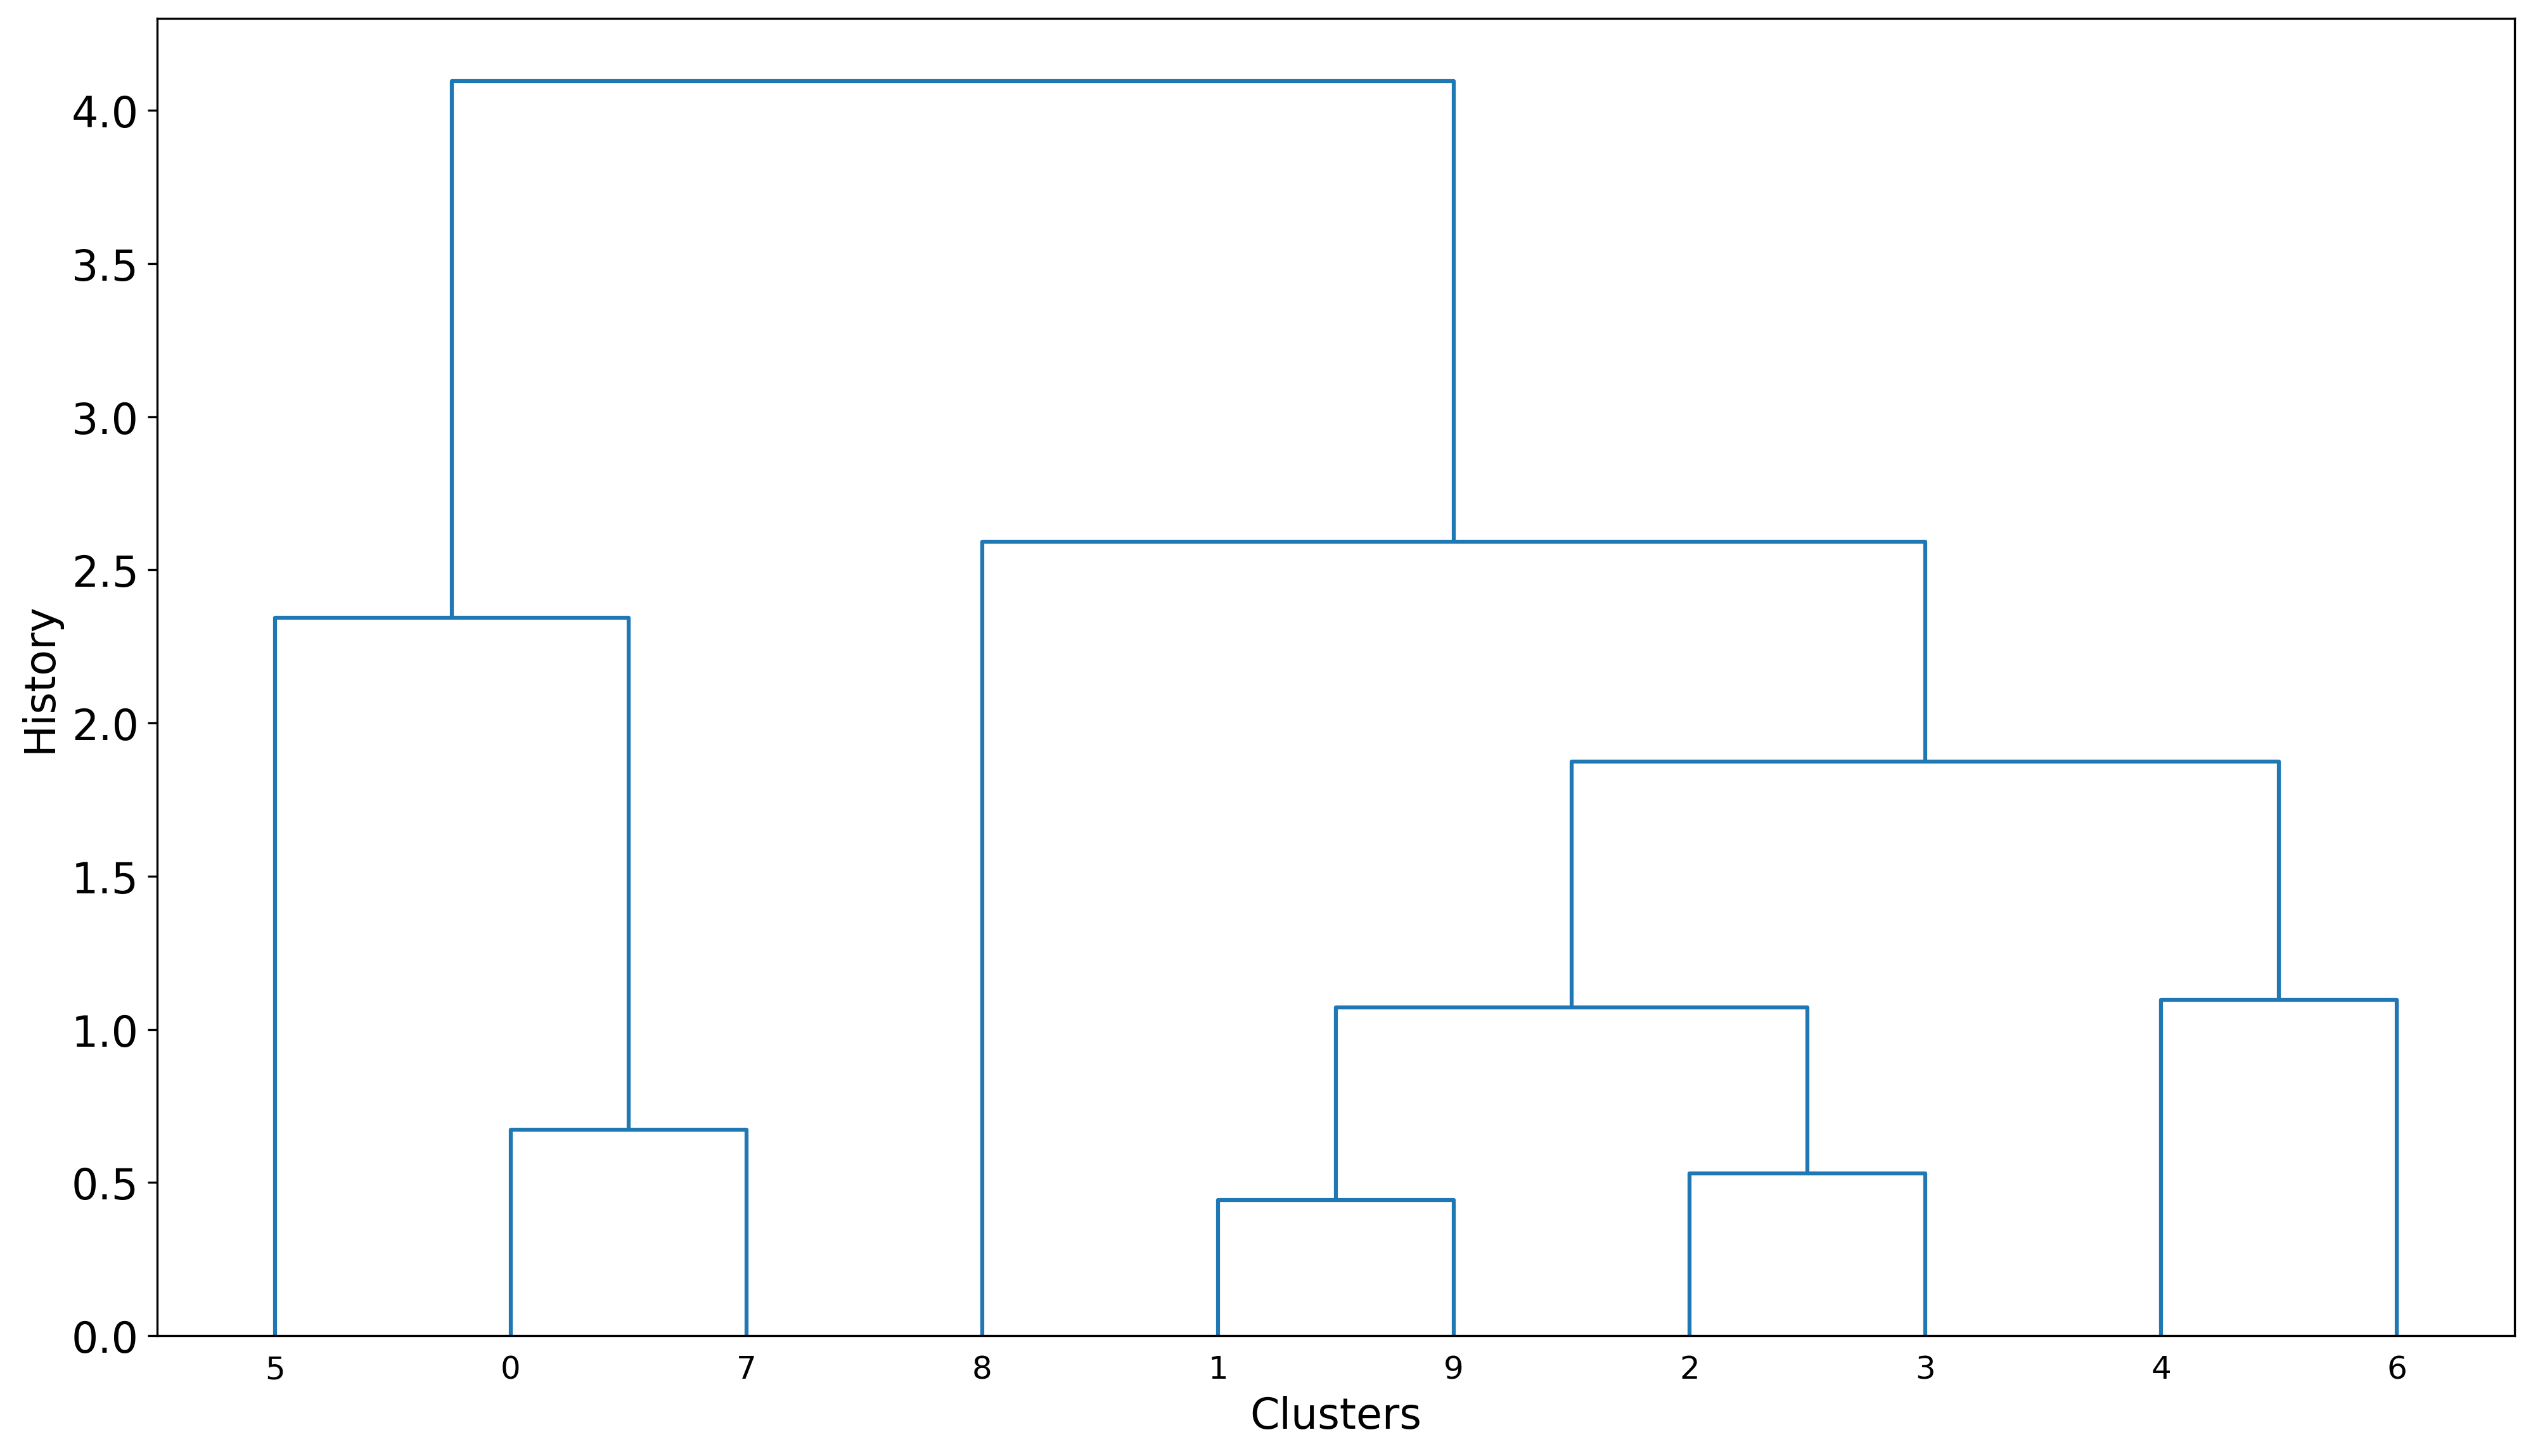

In [51]:
plt.figure()  
plt.xticks(fontsize = 50) 
Z = shc.linkage(X_train_scaled, method='complete') 

print(Z.round(2))  

D_c = shc.dendrogram(Z,color_threshold=0.2,no_labels=False)  
agglo_c = AgglomerativeClustering(n_clusters=3, linkage='complete')  
agglo_c.fit(X_train_scaled)  
plt.xlabel('Clusters')  
plt.ylabel('History')  

plt.show() 


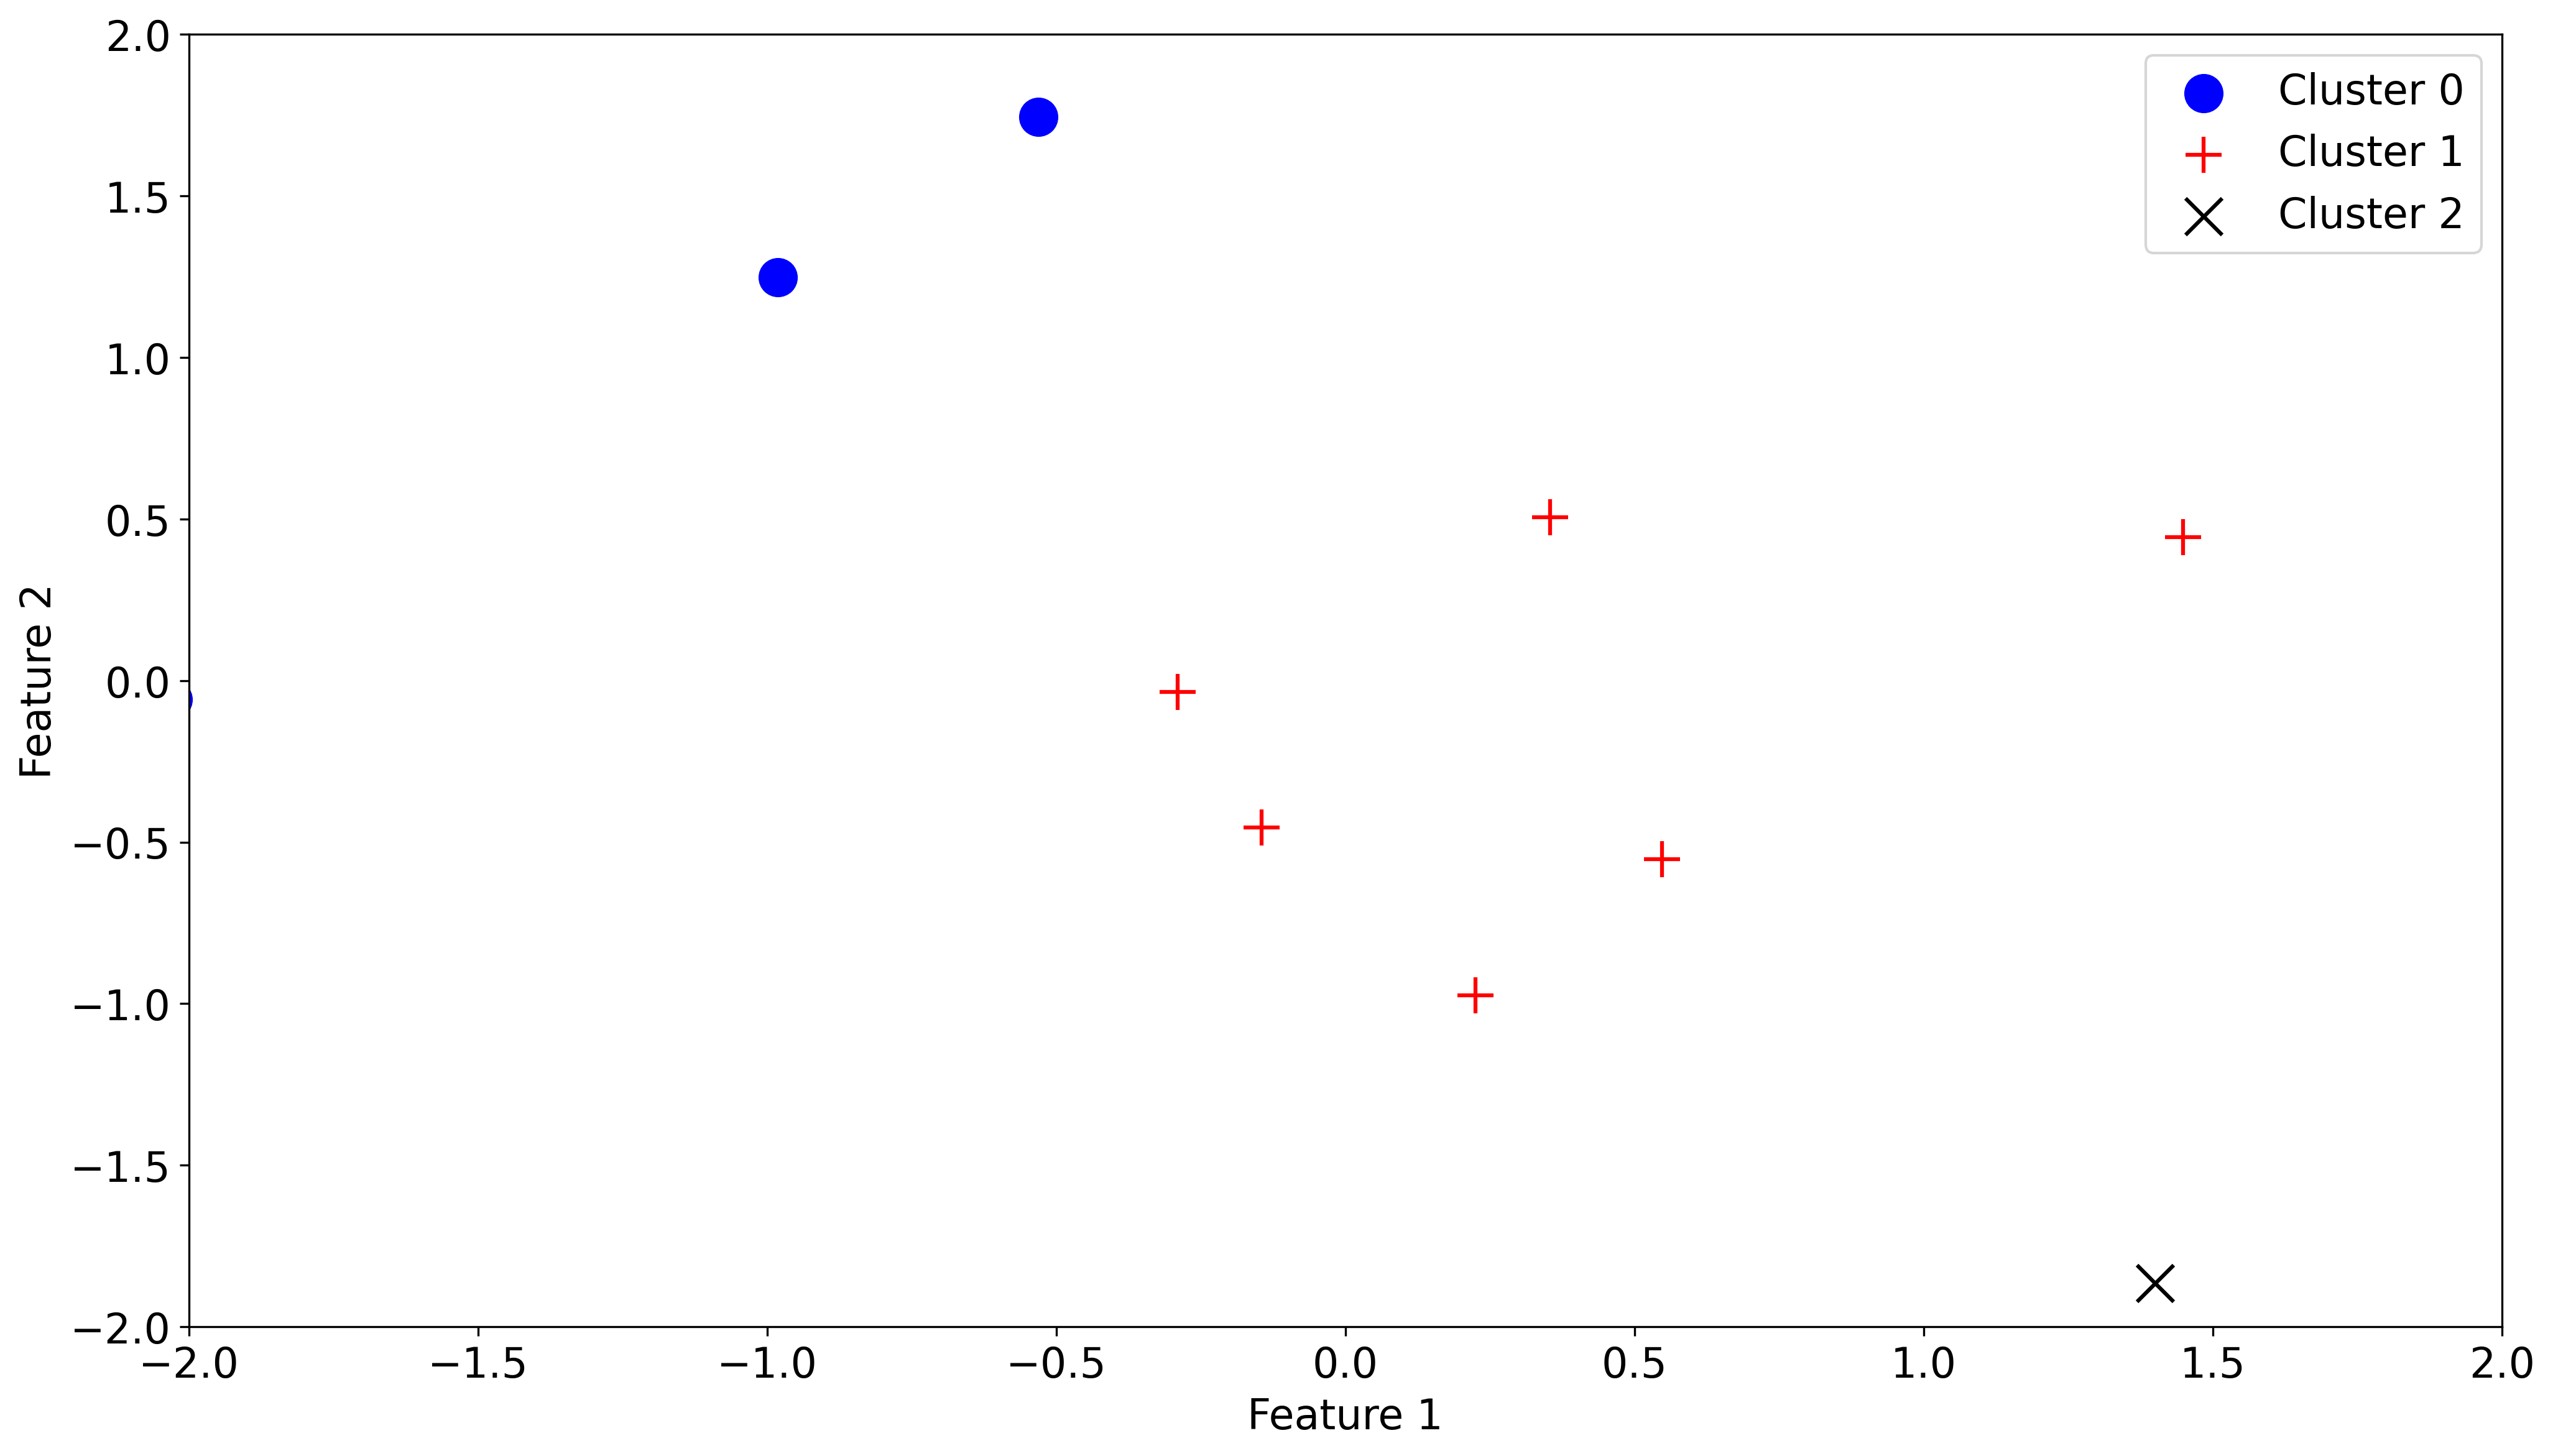

In [52]:
ref_0 = agglo_c.labels_ == 0  
ref_1 = agglo_c.labels_ == 1  
ref_2 = agglo_c.labels_ == 2  

X_train_scaled_0 = X_train_scaled[ref_0,:]  
X_train_scaled_1 = X_train_scaled[ref_1,:]  
X_train_scaled_2 = X_train_scaled[ref_2,:]  

plt.scatter(X_train_scaled_0[:, 0], X_train_scaled_0[:, 1], c='blue', marker='o', s=200,  label='Cluster 0')  
plt.scatter(X_train_scaled_1[:, 0], X_train_scaled_1[:, 1], c='red', marker='+', s=200,  label='Cluster 1')  
plt.scatter(X_train_scaled_2[:, 0], X_train_scaled_2[:, 1], c='black', marker='x', s=200,  label='Cluster 2')  

plt.xlim(-2, 2)  
plt.ylim(-2, 2)  
plt.xlabel('Feature 1')  
plt.ylabel('Feature 2')  
plt.legend(loc='best')  

plt.show() 

[[ 1.    9.    0.44  2.  ]
 [ 2.    3.    0.53  2.  ]
 [ 0.    7.    0.67  2.  ]
 [10.   11.    0.85  4.  ]
 [ 4.    6.    1.1   2.  ]
 [13.   14.    1.42  6.  ]
 [ 5.   12.    2.01  3.  ]
 [ 8.   15.    2.09  7.  ]
 [16.   17.    2.49 10.  ]]


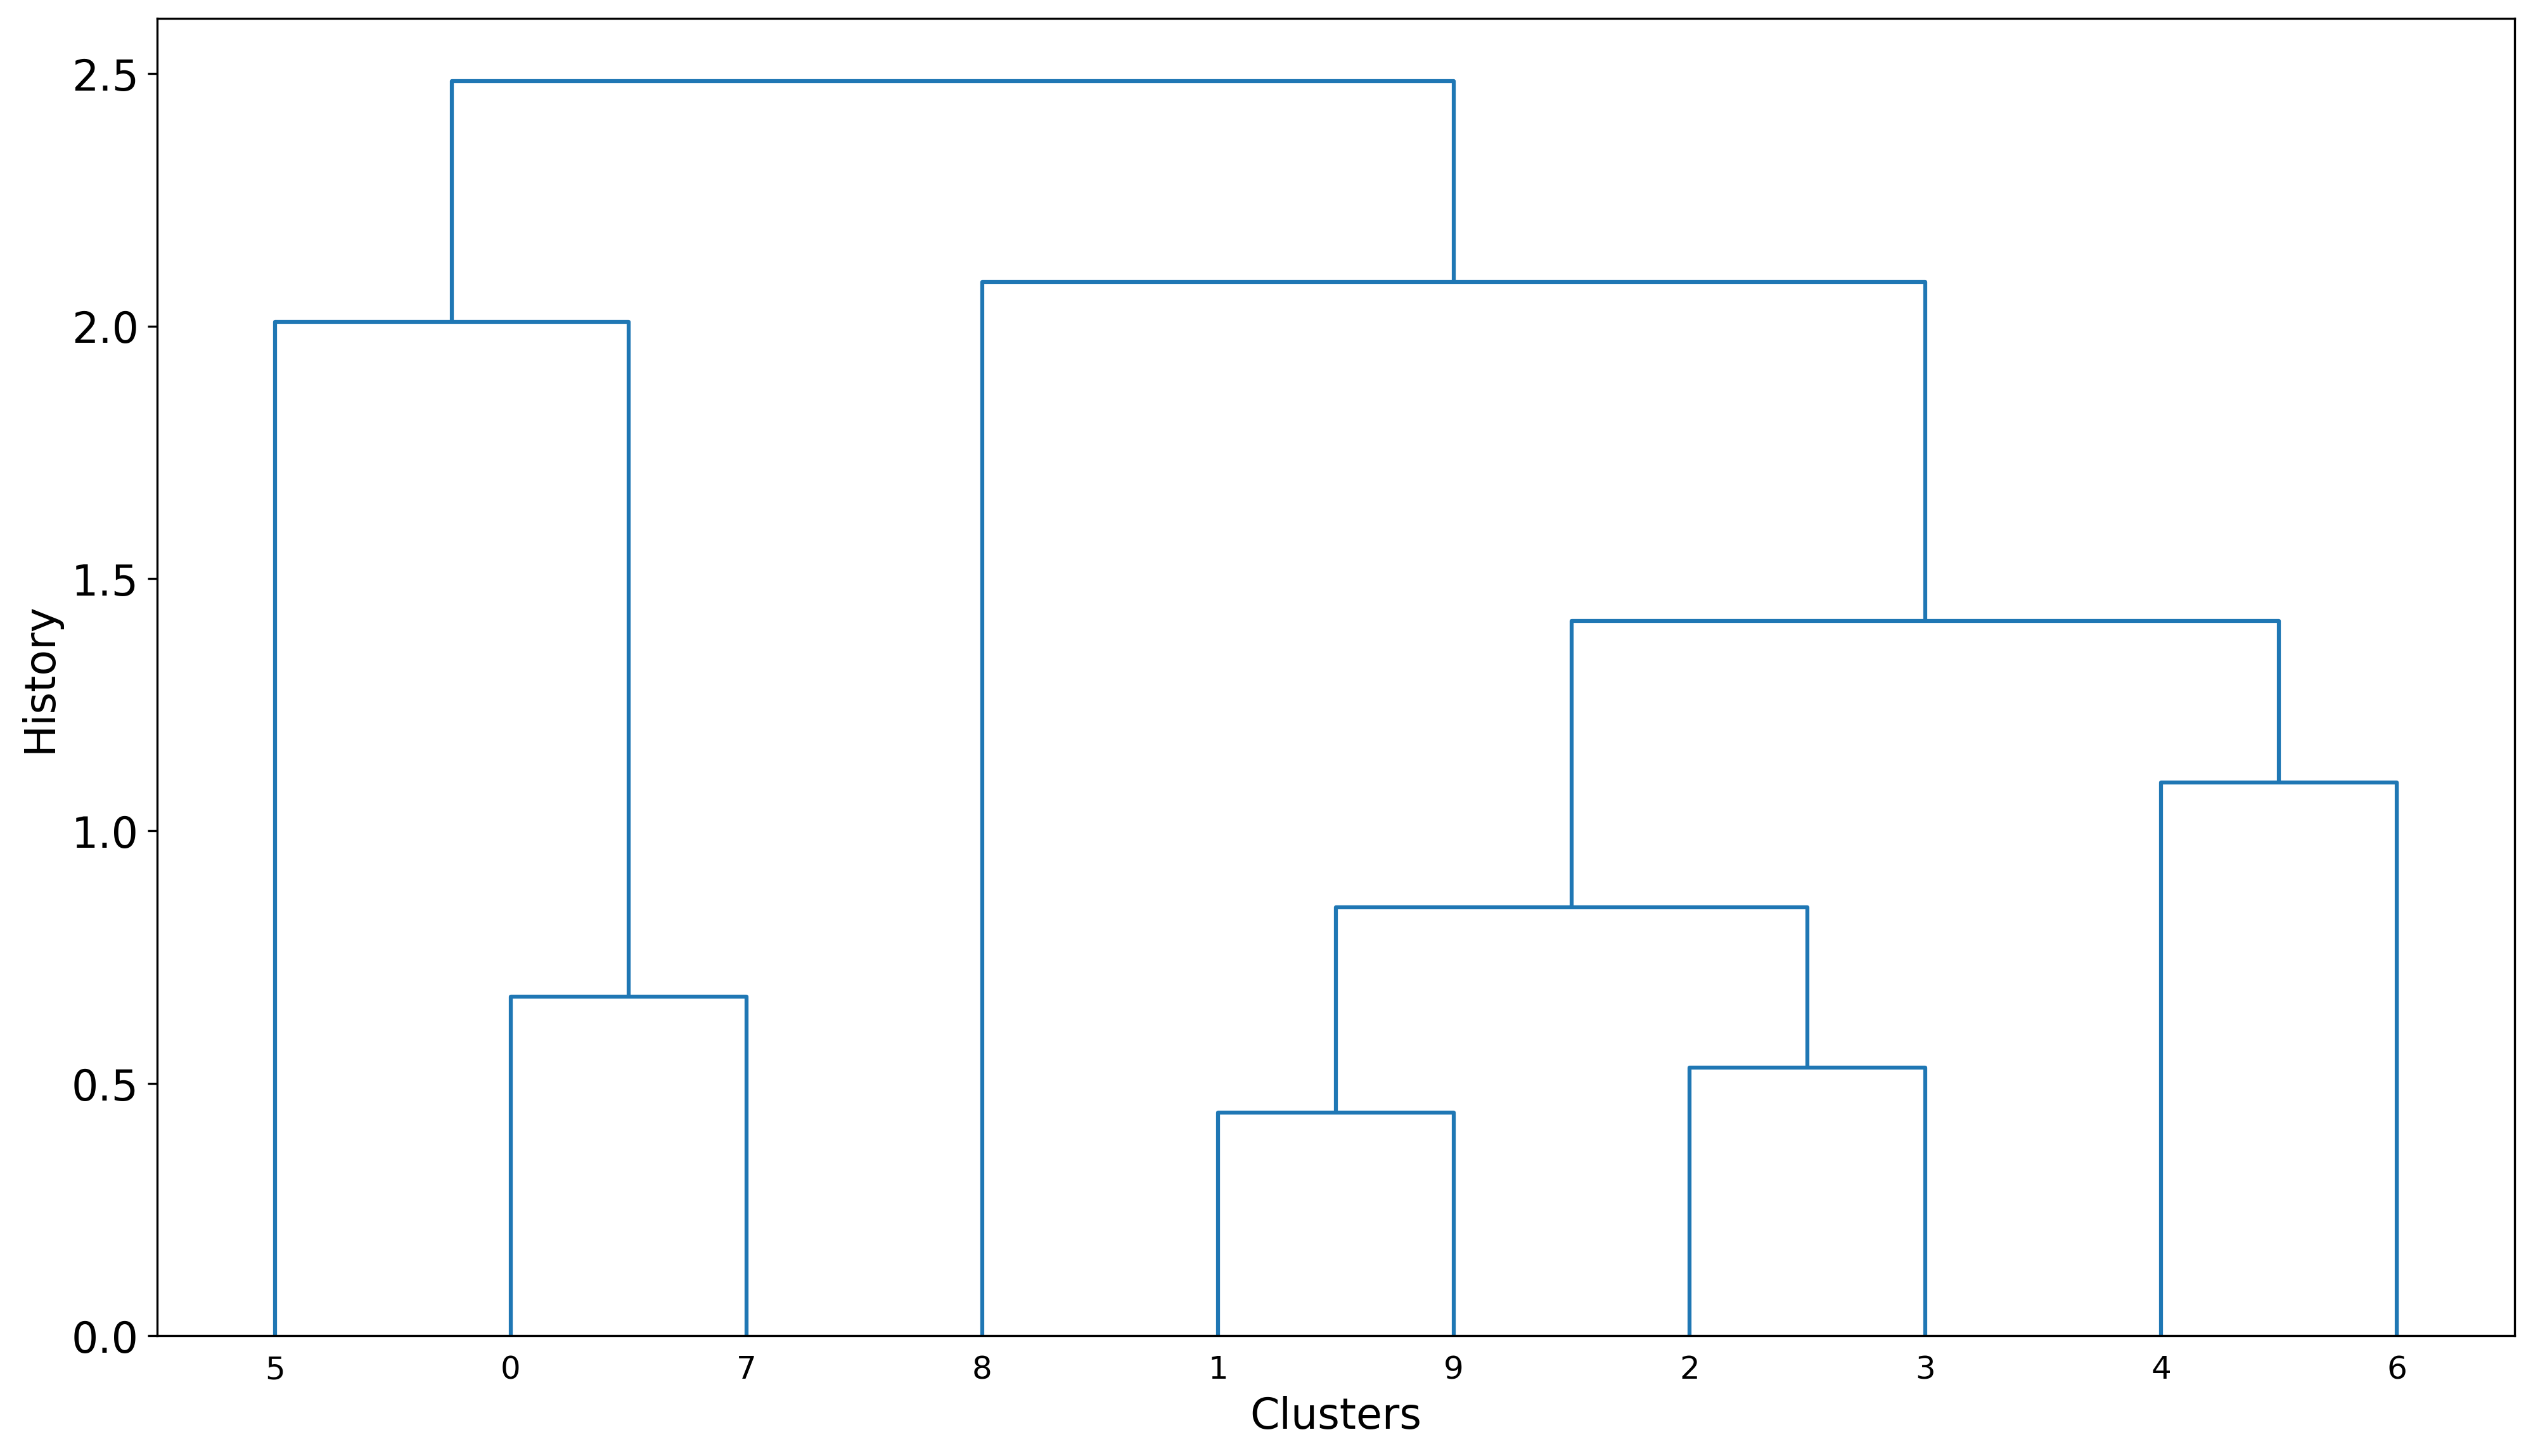

In [53]:
plt.figure()  
plt.xticks(fontsize = 50)

Z = shc.linkage(X_train_scaled, method='average')  
print(Z.round(2))  
D_a = shc.dendrogram(Z,color_threshold=0.2,  no_labels=False)  

agglo_a = AgglomerativeClustering(n_clusters=3, linkage='average')  
agglo_a.fit(X_train_scaled)

plt.xlabel('Clusters')  
plt.ylabel('History')  
plt.show() 


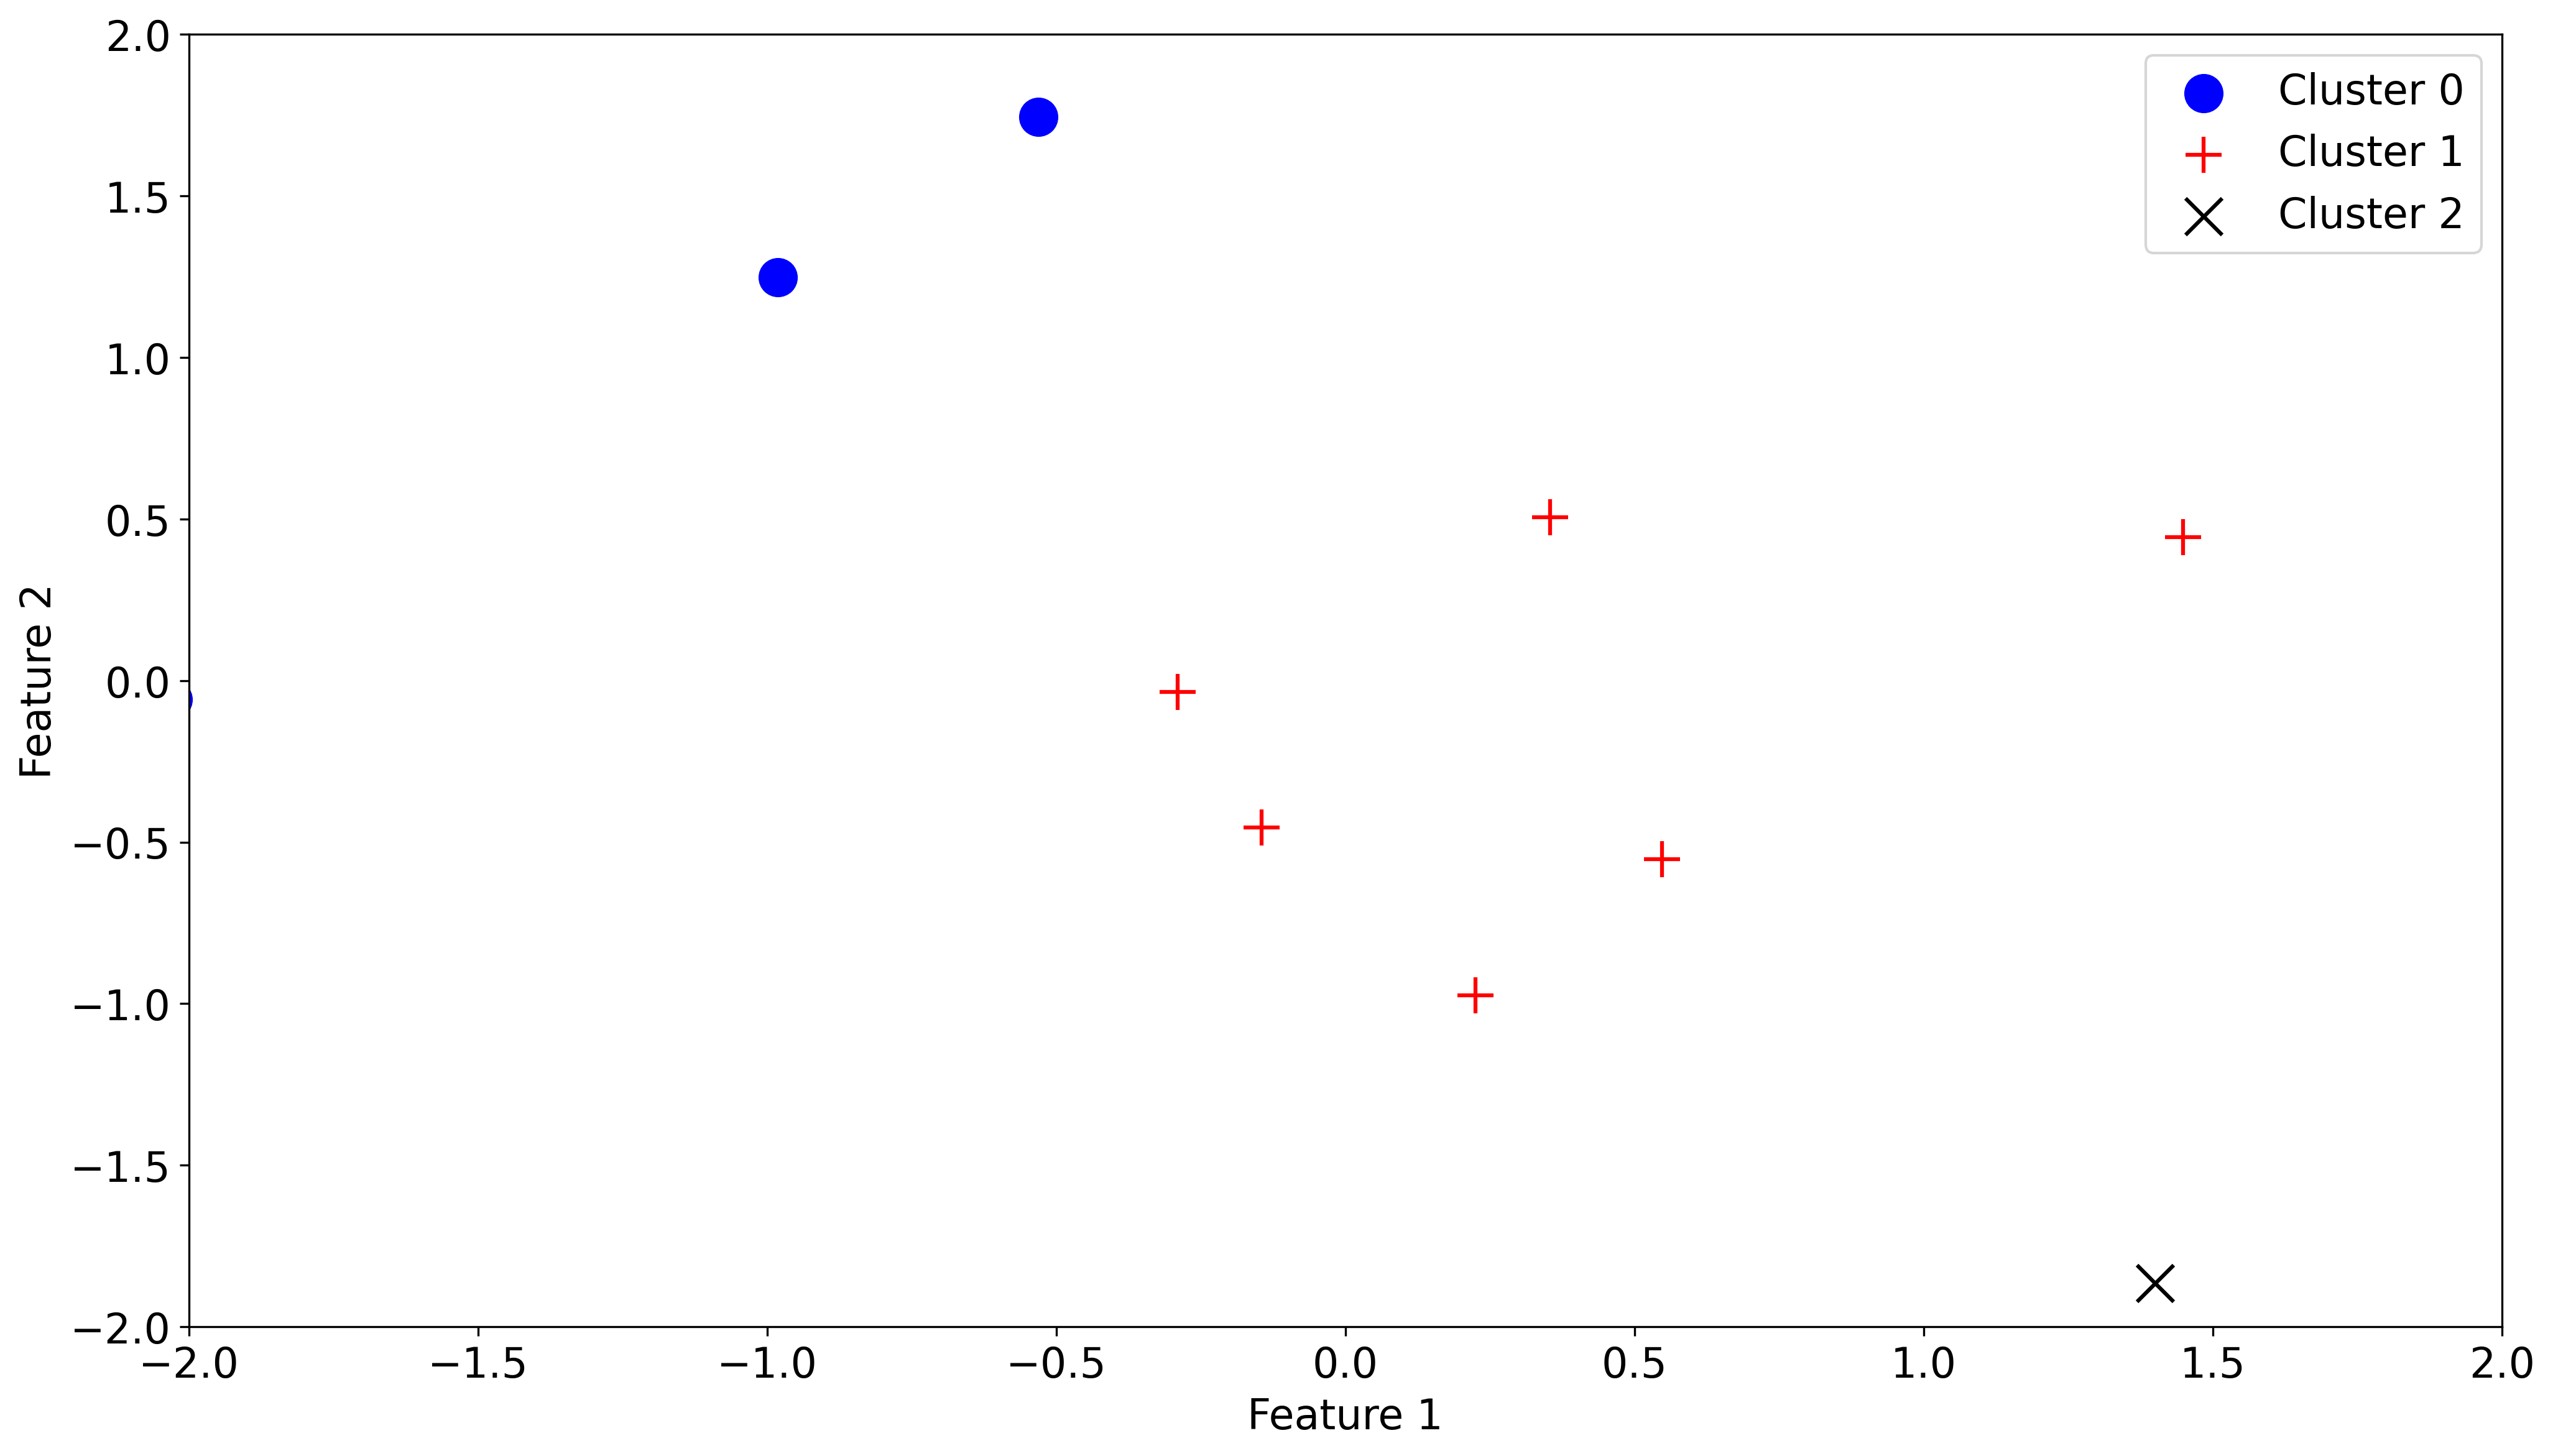

In [54]:
ref_0 = agglo_a.labels_ == 0 
ref_1 = agglo_a.labels_ == 1  
ref_2 = agglo_a.labels_ == 2 

X_train_scaled_0 = X_train_scaled[ref_0,:]  
X_train_scaled_1 = X_train_scaled[ref_1,:]  
X_train_scaled_2 = X_train_scaled[ref_2,:]  

plt.scatter(X_train_scaled_0[:, 0], X_train_scaled_0[:, 1], c='blue', marker='o', s=200,  label='Cluster 0')  
plt.scatter(X_train_scaled_1[:, 0], X_train_scaled_1[:, 1], c='red', marker='+', s=200,  label='Cluster 1') 
plt.scatter(X_train_scaled_2[:, 0], X_train_scaled_2[:, 1], c='black', marker='x', s=200,  label='Cluster 2')  

plt.xlim(-2, 2)  
plt.ylim(-2, 2)  
plt.xlabel('Feature 1')  
plt.ylabel('Feature 2')  
plt.legend(loc='best')  

plt.show() 

In [55]:
data = data.loc[data['state_orig_time'] != 'VI',:] #Virgin Island  
data = data.loc[data['state_orig_time'] != 'DC',:] #DC  
data = data.loc[data['state_orig_time'] != 'PR',:] #Puerto Rico  
data = data.loc[data['state_orig_time'] != 'nan',:] #Missing values  

#Drop states with no or only some defaults in the training set (til period 27) or NaN  
data = data.loc[data['state_orig_time'] != 'AL',:]  
data = data.loc[data['state_orig_time'] != 'AK',:] 
data = data.loc[data['state_orig_time'] != 'AR',:]  
data = data.loc[data['state_orig_time'] != 'ND',:]  
data = data.loc[data['state_orig_time'] != 'SD',:]  
data = data.loc[data['state_orig_time'] != 'MT',:]  
data = data.loc[data['state_orig_time'] != 'DE',:]  
data = data.loc[data['state_orig_time'] != 'WV',:]  
data = data.loc[data['state_orig_time'] != 'VT',:]  
data = data.loc[data['state_orig_time'] != 'ME',:]  
data = data.loc[data['state_orig_time'] != 'NE',:] 
data = data.loc[data['state_orig_time'] != 'NH',:]  
data = data.loc[data['state_orig_time'] != 'MS',:]  

scaler = StandardScaler()  
defaultrates_states1 = data.groupby(['time', 'state_orig_time'])['default_time'].mean().unstack(level=1).add_prefix('defaultrate_').fillna(0) 
defaultrates_states = scaler.fit_transform(defaultrates_states1)

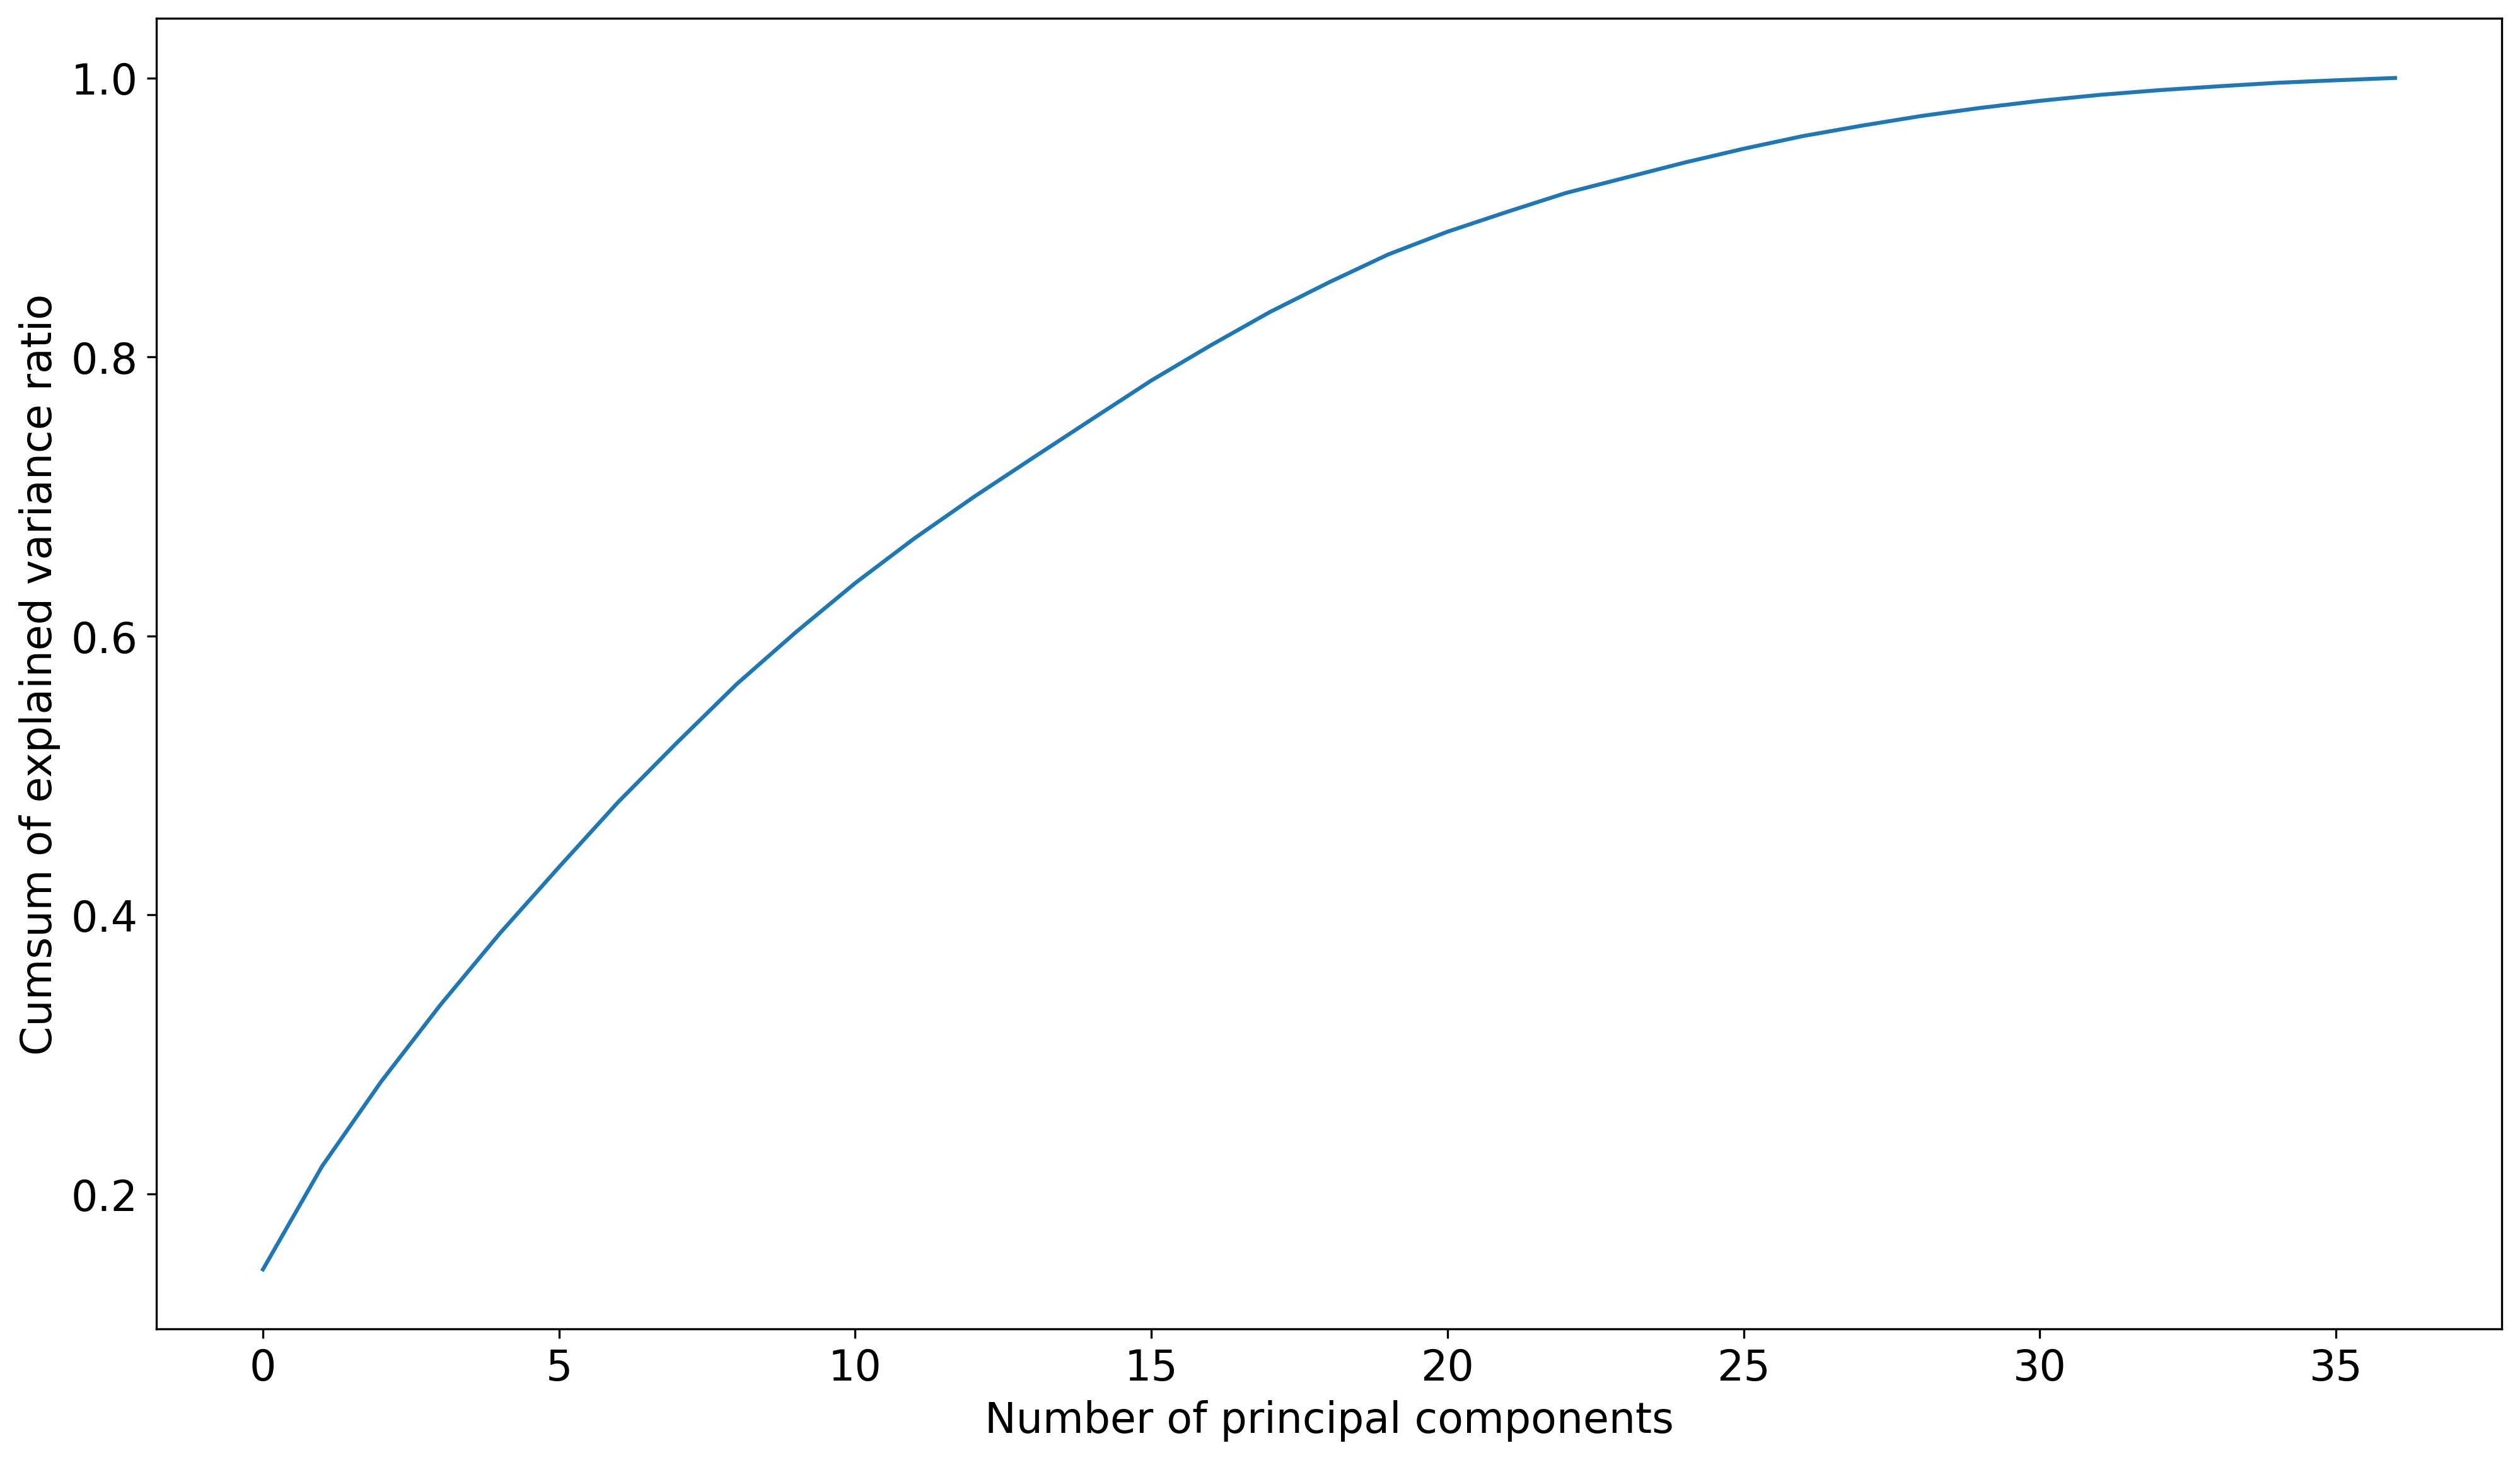

In [56]:
pca = PCA()  
pca.fit(defaultrates_states)  
plt.plot(np.cumsum(pca.explained_variance_ratio_))  
plt.xlabel('Number of principal components') 
plt.ylabel('Cumsum of explained variance ratio') 

plt.show() 


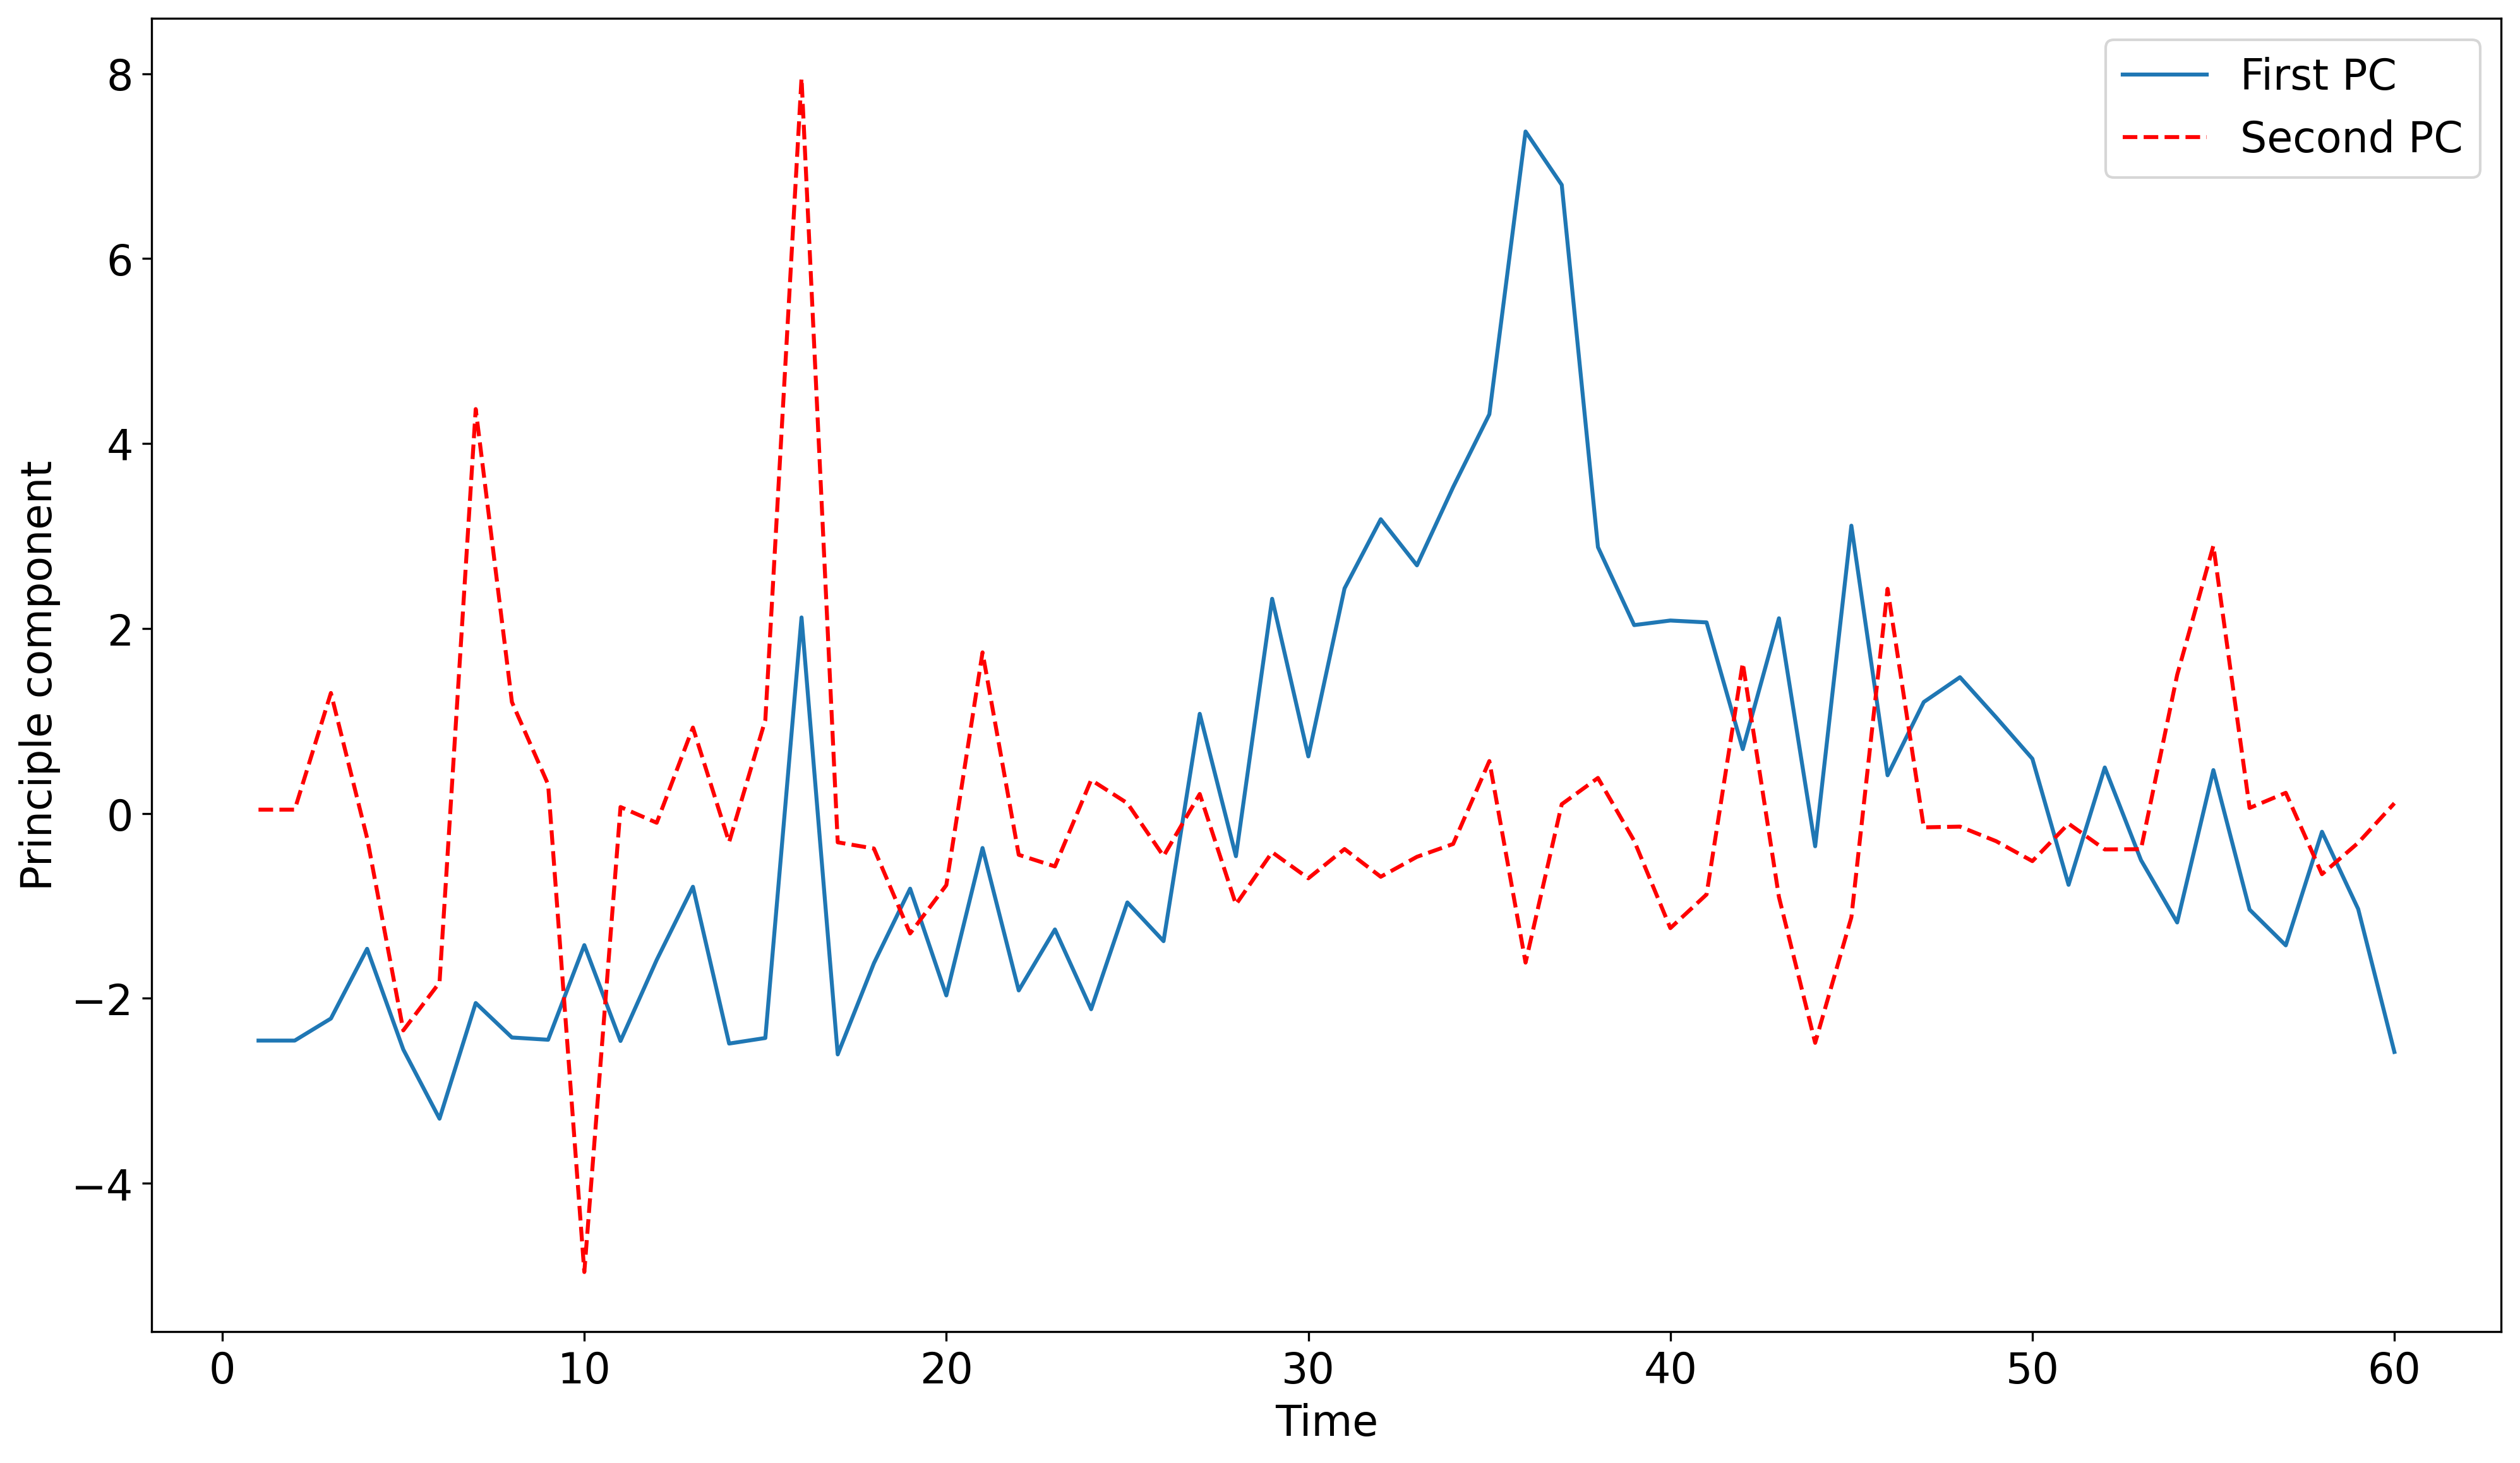

In [57]:
Z = pca.transform(defaultrates_states)  
plt.xlabel('Time')  
plt.ylabel('Principle component') 
plt.plot(defaultrates_states1.index, Z[:,0], alpha=1, label="First PC")  
plt.plot(defaultrates_states1.index, Z[:,1], alpha=1, color = 'red', linestyle='dashed',  label="Second PC")  
plt.legend(loc='best')  

plt.show() 


In [58]:
data, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data  , depvar='default_time', splitvar='time', threshold=26)
